In [1]:
# # Cell 0) (Optional) Install dependencies
# # Run this only if pyblip is not installed.

# !pip install pyblip cvxpy scikit-learn pandas numpy
# !pip install tqdm
# !Install NumPyro and JAX (for CPU/GPU support)
# !pip install numpyro jax jaxlib

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# !pip -q install pyblip tqdm scikit-learn pandas numpy

In [4]:
from pathlib import Path
import os, random
PROJECT_DIR = Path("/content/drive/MyDrive/BLiP")
DATA_DIR = PROJECT_DIR / "data"
OUT_DIR = PROJECT_DIR / "out"
save_folder = OUT_DIR / "VAE_ROC_Plots"
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR:", DATA_DIR)
print("OUT_DIR:", OUT_DIR)

PROJECT_DIR: /content/drive/MyDrive/BLiP
DATA_DIR: /content/drive/MyDrive/BLiP/data
OUT_DIR: /content/drive/MyDrive/BLiP/out


In [5]:
# Cell 1) Imports + Paths + Config

from __future__ import annotations

import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
os.environ.setdefault("PYTHONHASHSEED", str(RANDOM_STATE))

# RF settings (final model)
RF_N_ESTIMATORS = 300
RF_MAX_DEPTH = None

# Preprocessing toggle
USE_STANDARDIZE = True  # Fit on TRAIN only, apply to TEST (no leakage)

# Paths: assuming notebook is in BLiP/code/


X_TRAIN_PATH = DATA_DIR / "X_train.csv"
X_TEST_PATH  = DATA_DIR / "X_test.csv"
Y_TRAIN_PATH = DATA_DIR / "y_train.csv"
Y_TEST_PATH  = DATA_DIR / "y_test.csv"

print("DATA_DIR:", DATA_DIR)
print("Files exist:",
      X_TRAIN_PATH.exists(), X_TEST_PATH.exists(),
      Y_TRAIN_PATH.exists(), Y_TEST_PATH.exists())

DATA_DIR: /content/drive/MyDrive/BLiP/data
Files exist: True True True True


In [6]:
# Cell 2) Load data (GBM) + sanity checks

X_train_df = pd.read_csv(X_TRAIN_PATH)
X_test_df  = pd.read_csv(X_TEST_PATH)

y_train_df = pd.read_csv(Y_TRAIN_PATH)
y_test_df  = pd.read_csv(Y_TEST_PATH)

if y_train_df.shape[1] != 1 or y_test_df.shape[1] != 1:
    raise ValueError(
        f"Expected y_train/y_test to have exactly 1 column, "
        f"got y_train={y_train_df.shape}, y_test={y_test_df.shape}"
    )

y_train = y_train_df.iloc[:, 0].to_numpy().ravel().astype(int)
y_test  = y_test_df.iloc[:, 0].to_numpy().ravel().astype(int)

# Keep feature names
feature_names = list(X_train_df.columns)

# Convert to numpy
X_train = X_train_df.to_numpy(dtype=float)
X_test  = X_test_df.to_numpy(dtype=float)


# --- Force dtypes to match pyblip's Cython expectations (Windows-safe) ---

# y must be int32 / C-int (avoid int64)
y_train = np.asarray(y_train, dtype=np.intc)   # np.intc = C int (usually int32 on Windows)
y_test  = np.asarray(y_test,  dtype=np.intc)

# X must be float64 and C-contiguous
X_train = np.asarray(X_train, dtype=np.float64, order="C")
X_test  = np.asarray(X_test,  dtype=np.float64, order="C")

print("Dtypes check:")
print("  X_train:", X_train.dtype, "C_CONTIGUOUS:", X_train.flags["C_CONTIGUOUS"])
print("  y_train:", y_train.dtype)

print("=== Shapes ===")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)

print("\n=== Label check ===")
print("Train positive rate:", y_train.mean())
print("Test  positive rate:", y_test.mean())

# Basic consistency checks
if X_train.shape[1] != X_test.shape[1]:
    raise ValueError("Train/test feature dimension mismatch.")
if len(feature_names) != X_train.shape[1]:
    raise ValueError("Feature name length mismatch.")

Dtypes check:
  X_train: float64 C_CONTIGUOUS: True
  y_train: int32
=== Shapes ===
X_train: (82, 724) y_train: (82,)
X_test : (36, 724) y_test : (36,)

=== Label check ===
Train positive rate: 0.6585365853658537
Test  positive rate: 0.6666666666666666


In [7]:
# Cell 1) Imports + Config

import math
import copy
import random
import os

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import StratifiedShuffleSplit, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint

# -------------------------
# Reproducibility
# -------------------------
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# -------------------------
# Main switches
# -------------------------
MODEL_VARIANT = "vae"          # "vae" or "beta_tcvae"
INPUT_SOURCE = "selected"           # "selected" or "all"
LATENT_DIM = 2
HIDDEN_DIMS = [8,4]          # None -> auto based on input dim
DROPOUT = 0.20

# -------------------------
# Training hyperparameters
# -------------------------
LR = 5e-3
WEIGHT_DECAY = 1e-4
BATCH_SIZE = 8
MAX_EPOCHS = 20
PATIENCE = 20
VAL_SIZE = 0.20
GRAD_CLIP_NORM = 5.0

# -------------------------
# Loss weights
# -------------------------
RECON_WEIGHT = 2.0
BETA = 2.0
CLS_WEIGHT = 1.0
TC_WEIGHT = 2.0 if MODEL_VARIANT == "beta_tcvae" else 0.0

# -------------------------
# Optional downstream latent RF
# -------------------------
RUN_RF_ON_LATENT = True

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)
print("MODEL_VARIANT:", MODEL_VARIANT)
print("INPUT_SOURCE:", INPUT_SOURCE)

DEVICE: cuda
MODEL_VARIANT: vae
INPUT_SOURCE: selected


In [8]:
# Cell 2) CV-safe input helpers (NO global selected input)

from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler

# -------------------------
# SVM-based feature selection settings
# -------------------------
SVM_FS_C = 1.0
SVM_FS_MAX_FEATURES = 100
SVM_FS_EPS = 1e-8

def auto_hidden_dims(input_dim: int):
    if HIDDEN_DIMS is not None:
        return HIDDEN_DIMS
    if input_dim >= 512:
        return [256, 128]
    if input_dim >= 128:
        return [128, 64]
    if input_dim >= 32:
        return [64, 32]
    return [32, 16]

# raw matrix만 들고 있기
X_train_raw = np.asarray(X_train, dtype=np.float32)
X_test_raw  = np.asarray(X_test, dtype=np.float32)

y_train_np = np.asarray(y_train, dtype=np.int64).ravel()
y_test_np  = np.asarray(y_test, dtype=np.int64).ravel()

def fit_scaler_on_train(X_tr_raw):
    scaler = StandardScaler()
    X_tr_pp = scaler.fit_transform(X_tr_raw).astype(np.float32)
    return scaler, X_tr_pp

def transform_with_scaler(scaler, X_raw):
    return scaler.transform(X_raw).astype(np.float32)

def select_features_with_linear_svm(
    X_tr_pp,
    y_tr,
    C: float = SVM_FS_C,
    max_features: int = SVM_FS_MAX_FEATURES,
):
    """
    반드시 train split에서만 fit해야 함.
    """
    y_tr = np.asarray(y_tr).ravel().astype(int)

    svm_fs = LinearSVC(
        penalty="l1",
        dual=False,
        C=C,
        random_state=42,
        max_iter=20000,
    )
    svm_fs.fit(X_tr_pp, y_tr)

    coef_abs = np.abs(svm_fs.coef_).ravel()
    selected_idx = np.flatnonzero(coef_abs > SVM_FS_EPS)

    if len(selected_idx) == 0:
        top_k = min(max_features, X_tr_pp.shape[1])
        selected_idx = np.argsort(coef_abs)[::-1][:top_k]
    elif len(selected_idx) > max_features:
        ranked = selected_idx[np.argsort(coef_abs[selected_idx])[::-1]]
        selected_idx = ranked[:max_features]

    selected_idx = np.sort(selected_idx)
    return selected_idx, coef_abs

def prepare_input_split(
    X_tr_raw,
    y_tr,
    X_val_raw=None,
    X_test_raw=None,
    input_source: str = INPUT_SOURCE,
    use_standardize: bool = USE_STANDARDIZE,
    C: float = SVM_FS_C,
    max_features: int = SVM_FS_MAX_FEATURES,
):
    """
    CV-safe preprocessing:
    - scaler는 train split에만 fit
    - SVM feature selection도 train split에만 fit
    """
    X_tr_raw = np.asarray(X_tr_raw, dtype=np.float32)
    X_val_raw = None if X_val_raw is None else np.asarray(X_val_raw, dtype=np.float32)
    X_test_raw = None if X_test_raw is None else np.asarray(X_test_raw, dtype=np.float32)

    scaler = None
    if use_standardize:
        scaler, X_tr_base = fit_scaler_on_train(X_tr_raw)
        X_val_base = None if X_val_raw is None else transform_with_scaler(scaler, X_val_raw)
        X_test_base = None if X_test_raw is None else transform_with_scaler(scaler, X_test_raw)
    else:
        X_tr_base = X_tr_raw.astype(np.float32)
        X_val_base = None if X_val_raw is None else X_val_raw.astype(np.float32)
        X_test_base = None if X_test_raw is None else X_test_raw.astype(np.float32)

    info = {
        "scaler": scaler,
        "selected_idx": None,
        "coef_abs": None,
        "input_feature_names": list(feature_names) if "feature_names" in globals() else None,
    }

    if input_source == "all":
        return X_tr_base, X_val_base, X_test_base, info

    if input_source != "selected":
        raise ValueError("INPUT_SOURCE must be 'selected' or 'all'.")

    selected_idx, coef_abs = select_features_with_linear_svm(
        X_tr_base,
        y_tr,
        C=C,
        max_features=max_features,
    )

    X_tr_sel = X_tr_base[:, selected_idx]
    X_val_sel = None if X_val_base is None else X_val_base[:, selected_idx]
    X_test_sel = None if X_test_base is None else X_test_base[:, selected_idx]

    info["selected_idx"] = selected_idx
    info["coef_abs"] = coef_abs
    if "feature_names" in globals():
        info["input_feature_names"] = [feature_names[i] for i in selected_idx]

    return X_tr_sel, X_val_sel, X_test_sel, info

print("INPUT_SOURCE   :", INPUT_SOURCE)
print("Raw train shape:", X_train_raw.shape)
print("Raw test shape :", X_test_raw.shape)
print("Latent dim     :", LATENT_DIM)
print("Hidden dims    :", HIDDEN_DIMS, "(actual input_dim is decided inside each fold)")

INPUT_SOURCE   : selected
Raw train shape: (82, 724)
Raw test shape : (36, 724)
Latent dim     : 2
Hidden dims    : [8, 4] (actual input_dim is decided inside each fold)


In [9]:
# Cell 3) Model + losses + helper functions

class MLP(nn.Module):
    def __init__(self, in_dim, dims, dropout=0.10):
        super().__init__()
        layers = []
        prev = in_dim
        for d in dims:
            layers += [
                nn.Linear(prev, d),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev = d
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class SupervisedVAE(nn.Module):
    def __init__(self, input_dim, hidden_dims, latent_dim, dropout=0.10):
        super().__init__()

        self.encoder = MLP(input_dim, hidden_dims, dropout=dropout)
        last_h = hidden_dims[-1]

        self.mu_layer = nn.Linear(last_h, latent_dim)
        self.logvar_layer = nn.Linear(last_h, latent_dim)

        dec_dims = list(reversed(hidden_dims))
        decoder_layers = []
        prev = latent_dim
        for d in dec_dims:
            decoder_layers += [
                nn.Linear(prev, d),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev = d
        decoder_layers += [nn.Linear(prev, input_dim)]
        self.decoder = nn.Sequential(*decoder_layers)

        self.classifier = nn.Sequential(
            nn.Linear(latent_dim, max(8, latent_dim)),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(max(8, latent_dim), 1),
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu = self.mu_layer(h)
        logvar = torch.clamp(self.logvar_layer(h), min=-10.0, max=10.0)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decoder(z)

        # Classification from mu is usually more stable than from sampled z
        logits = self.classifier(mu)

        return {
            "mu": mu,
            "logvar": logvar,
            "z": z,
            "x_recon": x_recon,
            "logits": logits,
        }

def reconstruction_loss(x_recon, x):
    return F.mse_loss(x_recon, x, reduction="mean")

def kl_loss(mu, logvar):
    return (-0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum(dim=1)).mean()

def log_density_gaussian(x, mu, logvar):
    return -0.5 * (
        math.log(2 * math.pi) +
        logvar +
        ((x - mu) ** 2) / logvar.exp()
    )

def total_correlation(z, mu, logvar):
    # Practical minibatch approximation for TC
    batch_size, latent_dim = z.shape

    z_exp = z.unsqueeze(1)           # [B, 1, D]
    mu_exp = mu.unsqueeze(0)         # [1, B, D]
    logvar_exp = logvar.unsqueeze(0) # [1, B, D]

    mat_log_qz = log_density_gaussian(z_exp, mu_exp, logvar_exp)  # [B, B, D]

    log_qz = torch.logsumexp(mat_log_qz.sum(dim=2), dim=1) - math.log(batch_size)
    log_qz_product = (
        torch.logsumexp(mat_log_qz, dim=1) - math.log(batch_size)
    ).sum(dim=1)

    tc = (log_qz - log_qz_product).mean()
    return tc

def compute_loss_dict(model_out, x, y, pos_weight=None):
    recon = reconstruction_loss(model_out["x_recon"], x)
    kl = kl_loss(model_out["mu"], model_out["logvar"])

    if pos_weight is None:
        cls = F.binary_cross_entropy_with_logits(
            model_out["logits"].squeeze(1),
            y,
        )
    else:
        cls = F.binary_cross_entropy_with_logits(
            model_out["logits"].squeeze(1),
            y,
            pos_weight=pos_weight,
        )

    if MODEL_VARIANT == "beta_tcvae":
        tc = total_correlation(model_out["z"], model_out["mu"], model_out["logvar"])
    else:
        tc = torch.tensor(0.0, device=x.device)

    total = (
        RECON_WEIGHT * recon +
        BETA * kl +
        CLS_WEIGHT * cls +
        TC_WEIGHT * tc
    )

    return {
        "total": total,
        "recon": recon,
        "kl": kl,
        "cls": cls,
        "tc": tc,
    }

@torch.no_grad()
def predict_model(model, X_np, batch_size=256):
    loader = DataLoader(
        TensorDataset(torch.from_numpy(X_np).float()),
        batch_size=batch_size,
        shuffle=False,
    )

    model.eval()
    probs_all = []
    mu_all = []
    logits_all = []
    recon_all = []

    for (xb,) in loader:
        xb = xb.to(DEVICE)
        out = model(xb)

        probs = torch.sigmoid(out["logits"]).squeeze(1).cpu().numpy()
        mu = out["mu"].cpu().numpy()
        logits = out["logits"].squeeze(1).cpu().numpy()
        recon = out["x_recon"].cpu().numpy()

        probs_all.append(probs)
        mu_all.append(mu)
        logits_all.append(logits)
        recon_all.append(recon)

    return {
        "proba": np.concatenate(probs_all),
        "mu": np.vstack(mu_all),
        "logits": np.concatenate(logits_all),
        "recon": np.vstack(recon_all),
    }

def choose_threshold_by_youden(y_true, y_proba):
    best_thr = 0.5
    best_score = -np.inf

    for thr in np.linspace(0.05, 0.95, 181):
        y_pred = (y_proba >= thr).astype(int)

        tp = ((y_pred == 1) & (y_true == 1)).sum()
        tn = ((y_pred == 0) & (y_true == 0)).sum()
        fp = ((y_pred == 1) & (y_true == 0)).sum()
        fn = ((y_pred == 0) & (y_true == 1)).sum()

        tpr = tp / max(tp + fn, 1)
        tnr = tn / max(tn + fp, 1)
        score = tpr + tnr - 1

        if score > best_score:
            best_score = score
            best_thr = float(thr)

    return best_thr

def evaluate_predictions(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    auc = roc_auc_score(y_true, y_proba) if len(np.unique(y_true)) == 2 else np.nan
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, digits=4, zero_division=0)

    return {
        "auc": auc,
        "acc": acc,
        "cm": cm,
        "report": report,
    }

In [10]:
# Cell 3.5) CV helper: one fold training

MIN_DELTA = 0.0   # 0.01로 줘도 됨

def make_fold_loaders_and_pos_weight(X_tr, y_tr, X_val, y_val):
    train_ds = TensorDataset(
        torch.from_numpy(X_tr).float(),
        torch.from_numpy(y_tr).float(),
    )
    val_ds = TensorDataset(
        torch.from_numpy(X_val).float(),
        torch.from_numpy(y_val).float(),
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=min(BATCH_SIZE, len(train_ds)),
        shuffle=True,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=min(BATCH_SIZE, len(val_ds)),
        shuffle=False,
    )

    n_pos = int((y_tr == 1).sum())
    n_neg = int((y_tr == 0).sum())
    pos_weight = torch.tensor(
        [n_neg / max(n_pos, 1)],
        dtype=torch.float32,
        device=DEVICE,
    )

    return train_loader, val_loader, pos_weight


def train_one_fold(X_tr, y_tr, X_val, y_val, fold_id=1):
    seed_everything(42 + fold_id)

    train_loader, val_loader, pos_weight = make_fold_loaders_and_pos_weight(
        X_tr, y_tr, X_val, y_val
    )

    input_dim_fold = X_tr.shape[1]
    hidden_dims_fold = auto_hidden_dims(input_dim_fold)

    model = SupervisedVAE(
      input_dim=input_dim_fold,
      hidden_dims=hidden_dims_fold,
      latent_dim=LATENT_DIM,
      dropout=DROPOUT,
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY,
    )

    best_state = None
    best_val_auc = -np.inf
    best_epoch = -1
    epochs_no_improve = 0
    history = []

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()

        train_total = 0.0
        train_recon = 0.0
        train_kl = 0.0
        train_cls = 0.0
        train_tc = 0.0
        train_n = 0

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()

            out = model(xb)
            loss_dict = compute_loss_dict(out, xb, yb, pos_weight=pos_weight)

            loss_dict["total"].backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            optimizer.step()

            bs = xb.size(0)
            train_total += loss_dict["total"].item() * bs
            train_recon += loss_dict["recon"].item() * bs
            train_kl += loss_dict["kl"].item() * bs
            train_cls += loss_dict["cls"].item() * bs
            train_tc += loss_dict["tc"].item() * bs
            train_n += bs

        train_pred = predict_model(model, X_tr)
        val_pred = predict_model(model, X_val)

        train_auc = roc_auc_score(y_tr, train_pred["proba"])
        val_auc = roc_auc_score(y_val, val_pred["proba"])

        epoch_row = {
            "fold": fold_id,
            "epoch": epoch,
            "train_total": train_total / train_n,
            "train_recon": train_recon / train_n,
            "train_kl": train_kl / train_n,
            "train_cls": train_cls / train_n,
            "train_tc": train_tc / train_n,
            "train_auc": train_auc,
            "val_auc": val_auc,
        }
        history.append(epoch_row)

        if epoch == 1 or epoch % 10 == 0:
            print(
                f"[Fold {fold_id} | Epoch {epoch:03d}] "
                f"train_total={epoch_row['train_total']:.4f} | "
                f"train_auc={train_auc:.4f} | "
                f"val_auc={val_auc:.4f}"
            )

        if val_auc > best_val_auc + MIN_DELTA:
            best_val_auc = val_auc
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= PATIENCE:
            print(
                f"Early stopping on fold {fold_id} at epoch {epoch}. "
                f"Best epoch: {best_epoch}, best val AUC: {best_val_auc:.4f}"
            )
            break

    if best_state is None:
        raise RuntimeError(f"Fold {fold_id} failed: best_state is None.")

    model.load_state_dict(best_state)

    train_pred = predict_model(model, X_tr)
    val_pred = predict_model(model, X_val)

    result = {
    "fold": fold_id,
    "best_epoch": best_epoch,
    "best_val_auc": float(roc_auc_score(y_val, val_pred["proba"])),
    "train_auc_at_best": float(roc_auc_score(y_tr, train_pred["proba"])),
    "history_df": pd.DataFrame(history),
    "model_state": copy.deepcopy(model.state_dict()),
    "val_proba": val_pred["proba"].copy(),
    "y_val": y_val.copy(),
    }
    return result

In [11]:
# Cell 4) 5-fold CV training + OOF predictions

CV_FOLDS = 5
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)

cv_results = []
fold_histories = {}
fold_states = {}
fold_val_outputs = {}

oof_proba = np.full(len(y_train_np), np.nan, dtype=np.float32)
oof_y = y_train_np.copy()
oof_fold = np.full(len(y_train_np), -1, dtype=np.int32)

CV_FOLDS = 5
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)

cv_results = []
fold_histories = {}
fold_states = {}
fold_val_outputs = {}
fold_preprocess_info = {}

oof_proba = np.full(len(y_train_np), np.nan, dtype=np.float32)
oof_y = y_train_np.copy()
oof_fold = np.full(len(y_train_np), -1, dtype=np.int32)

for fold_id, (tr_idx, val_idx) in enumerate(skf.split(X_train_raw, y_train_np), start=1):
    X_tr_raw_fold = X_train_raw[tr_idx]
    X_val_raw_fold = X_train_raw[val_idx]
    y_tr = y_train_np[tr_idx]
    y_val = y_train_np[val_idx]

    X_tr, X_val, _, prep_info = prepare_input_split(
        X_tr_raw=X_tr_raw_fold,
        y_tr=y_tr,
        X_val_raw=X_val_raw_fold,
        X_test_raw=None,
        input_source=INPUT_SOURCE,
        use_standardize=USE_STANDARDIZE,
        C=SVM_FS_C,
        max_features=SVM_FS_MAX_FEATURES,
    )

    print("\n" + "=" * 70)
    print(f"Fold {fold_id}/{CV_FOLDS}")
    print("Train split raw   :", X_tr_raw_fold.shape, "Pos rate:", y_tr.mean())
    print("Val split raw     :", X_val_raw_fold.shape, "Pos rate:", y_val.mean())
    print("Train input shape :", X_tr.shape)
    print("Val input shape   :", X_val.shape)

    if prep_info["selected_idx"] is not None:
        print(f"[Fold {fold_id}] selected {len(prep_info['selected_idx'])} features")
        if prep_info["input_feature_names"] is not None:
            print(f"[Fold {fold_id}] first selected features:",
                  prep_info["input_feature_names"][:10])

    fold_out = train_one_fold(X_tr, y_tr, X_val, y_val, fold_id=fold_id)

    cv_results.append({
        "fold": fold_out["fold"],
        "best_epoch": fold_out["best_epoch"],
        "train_auc_at_best": fold_out["train_auc_at_best"],
        "best_val_auc": fold_out["best_val_auc"],
        "n_features": int(X_tr.shape[1]),
    })

    fold_histories[fold_id] = fold_out["history_df"]
    fold_states[fold_id] = fold_out["model_state"]
    fold_preprocess_info[fold_id] = prep_info

    fold_val_outputs[fold_id] = {
        "y_val": fold_out["y_val"].copy(),
        "proba": fold_out["val_proba"].copy(),
    }

    oof_proba[val_idx] = fold_out["val_proba"]
    oof_fold[val_idx] = fold_id

cv_df = pd.DataFrame(cv_results)
display(cv_df)

if np.isnan(oof_proba).any():
    raise RuntimeError("OOF predictions contain NaN values. Check CV loop.")

oof_auc = roc_auc_score(oof_y, oof_proba)

print("\nCV summary")
print("Mean val AUC :", cv_df["best_val_auc"].mean())
print("Std  val AUC :", cv_df["best_val_auc"].std(ddof=1))
print("Mean epoch   :", cv_df["best_epoch"].mean())
print("Median epoch :", cv_df["best_epoch"].median())
print("Mean n_feat  :", cv_df["n_features"].mean())
print("OOF AUC      :", oof_auc)


Fold 1/5
Train split raw   : (65, 724) Pos rate: 0.6615384615384615
Val split raw     : (17, 724) Pos rate: 0.6470588235294118
Train input shape : (65, 39)
Val input shape   : (17, 39)
[Fold 1] selected 39 features
[Fold 1] first selected features: ['INTENSITY_Mean_ED_T2', 'HISTO_ET_T1Gd_Bin1', 'HISTO_ET_T1Gd_Bin9', 'HISTO_NET_T1Gd_Bin3', 'HISTO_ED_T1_Bin2', 'HISTO_ET_T2_Bin3', 'HISTO_ET_T2_Bin4', 'HISTO_ED_T2_Bin1', 'HISTO_ED_T2_Bin2', 'HISTO_NET_T2_Bin10']
[Fold 1 | Epoch 001] train_total=2.7584 | train_auc=0.4186 | val_auc=0.3485
[Fold 1 | Epoch 010] train_total=2.5024 | train_auc=0.8404 | val_auc=0.4394
[Fold 1 | Epoch 020] train_total=2.4695 | train_auc=0.9619 | val_auc=0.3788

Fold 2/5
Train split raw   : (65, 724) Pos rate: 0.6615384615384615
Val split raw     : (17, 724) Pos rate: 0.6470588235294118
Train input shape : (65, 43)
Val input shape   : (17, 43)
[Fold 2] selected 43 features
[Fold 2] first selected features: ['VOLUME_BRAIN', 'INTENSITY_STD_ET_T1Gd', 'INTENSITY_Mean_

,fold,best_epoch,train_auc_at_best,best_val_auc,n_features
0,1,10,0.840381,0.439394,39
1,2,1,0.645877,0.772727,43
2,3,7,0.441860,0.727273,52
3,4,9,0.734075,0.800000,48
4,5,18,0.930785,0.850000,49



CV summary
Mean val AUC : 0.7178787878787879
Std  val AUC : 0.16190299672626196
Mean epoch   : 9.0
Median epoch : 9.0
Mean n_feat  : 46.2
OOF AUC      : 0.5972222222222223


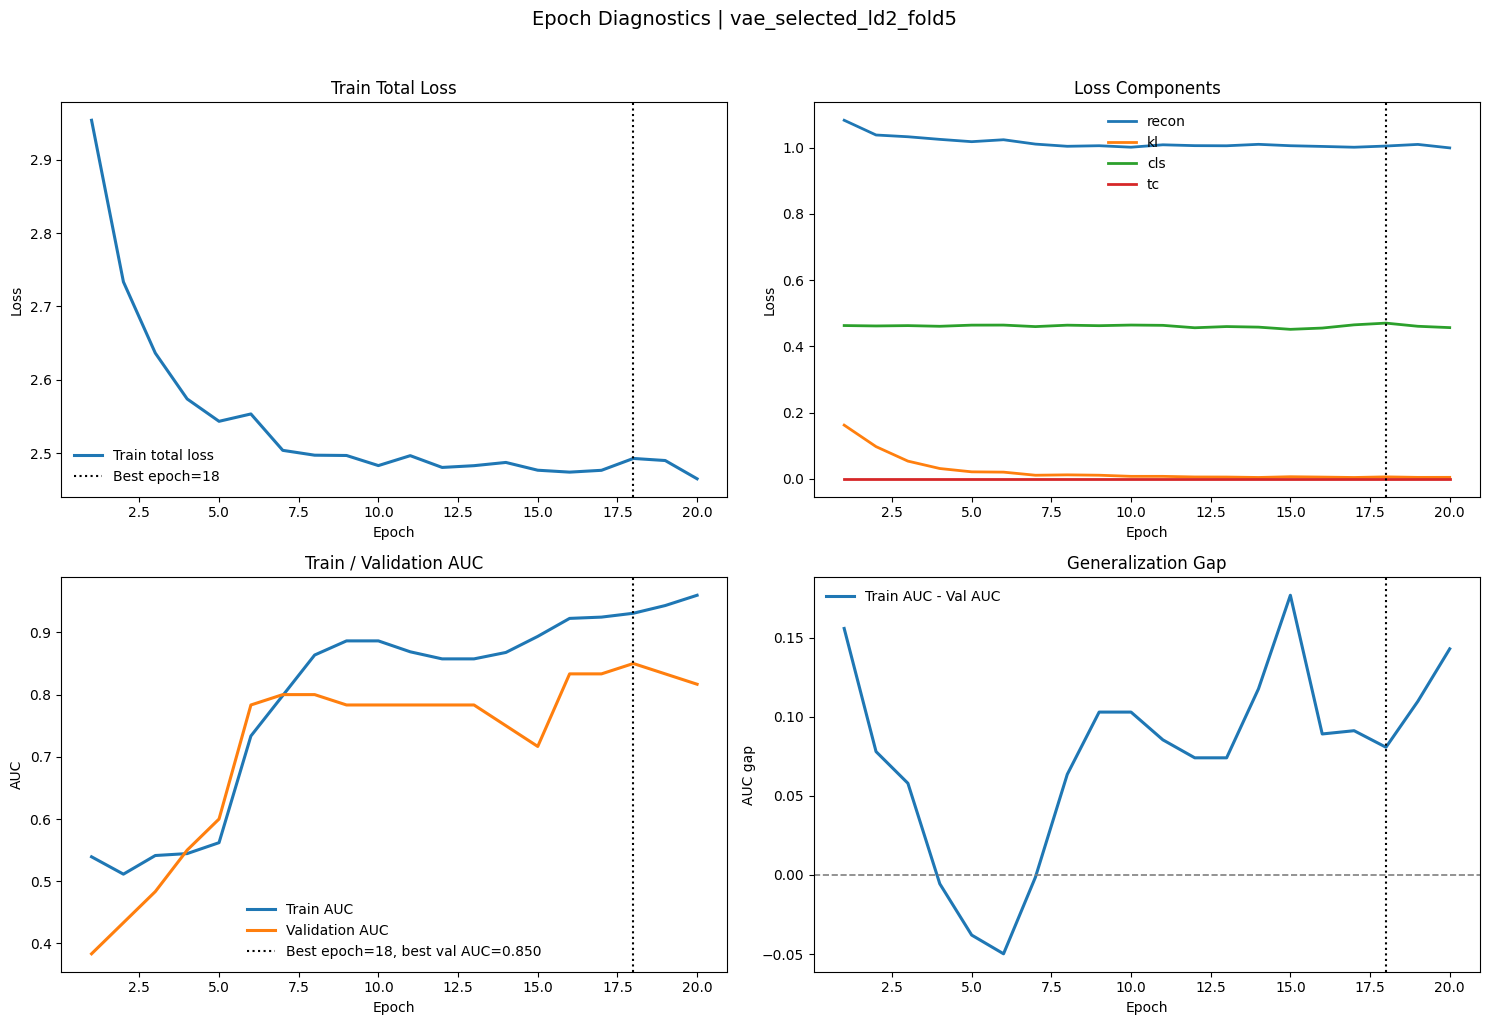

[SAVED] /content/drive/MyDrive/BLiP/out/figure_vae_tuning/epoch_diagnostics_vae_selected_ld2_fold5.png


In [12]:
# Cell 4.1) Plot one fold history

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

FIG_DIR = OUT_DIR / "figure_vae_tuning"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def plot_epoch_diagnostics(history_df, model_tag="vae_run", save_dir=FIG_DIR):
    hist = history_df.copy()

    best_idx = hist["val_auc"].idxmax()
    best_epoch = int(hist.loc[best_idx, "epoch"])
    best_val_auc = float(hist.loc[best_idx, "val_auc"])

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    axes[0, 0].plot(hist["epoch"], hist["train_total"], lw=2.2, label="Train total loss")
    axes[0, 0].axvline(best_epoch, ls=":", lw=1.5, color="black", label=f"Best epoch={best_epoch}")
    axes[0, 0].set_title("Train Total Loss")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Loss")
    axes[0, 0].legend(frameon=False)

    for col in ["train_recon", "train_kl", "train_cls", "train_tc"]:
        if col in hist.columns:
            axes[0, 1].plot(hist["epoch"], hist[col], lw=2.0, label=col.replace("train_", ""))
    axes[0, 1].axvline(best_epoch, ls=":", lw=1.5, color="black")
    axes[0, 1].set_title("Loss Components")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("Loss")
    axes[0, 1].legend(frameon=False)

    axes[1, 0].plot(hist["epoch"], hist["train_auc"], lw=2.2, label="Train AUC")
    axes[1, 0].plot(hist["epoch"], hist["val_auc"], lw=2.2, label="Validation AUC")
    axes[1, 0].axvline(
        best_epoch,
        ls=":",
        lw=1.5,
        color="black",
        label=f"Best epoch={best_epoch}, best val AUC={best_val_auc:.3f}"
    )
    axes[1, 0].set_title("Train / Validation AUC")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("AUC")
    axes[1, 0].legend(frameon=False)

    gap = hist["train_auc"] - hist["val_auc"]
    axes[1, 1].plot(hist["epoch"], gap, lw=2.2, label="Train AUC - Val AUC")
    axes[1, 1].axhline(0, ls="--", lw=1.2, color="gray")
    axes[1, 1].axvline(best_epoch, ls=":", lw=1.5, color="black")
    axes[1, 1].set_title("Generalization Gap")
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].set_ylabel("AUC gap")
    axes[1, 1].legend(frameon=False)

    fig.suptitle(f"Epoch Diagnostics | {model_tag}", y=1.02, fontsize=14)
    fig.tight_layout()

    out_path = save_dir / f"epoch_diagnostics_{model_tag}.png"
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"[SAVED] {out_path}")

best_fold = int(cv_df.loc[cv_df["best_val_auc"].idxmax(), "fold"])
plot_epoch_diagnostics(
    fold_histories[best_fold],
    model_tag=f"{MODEL_VARIANT}_{INPUT_SOURCE}_ld{LATENT_DIM}_fold{best_fold}"
)

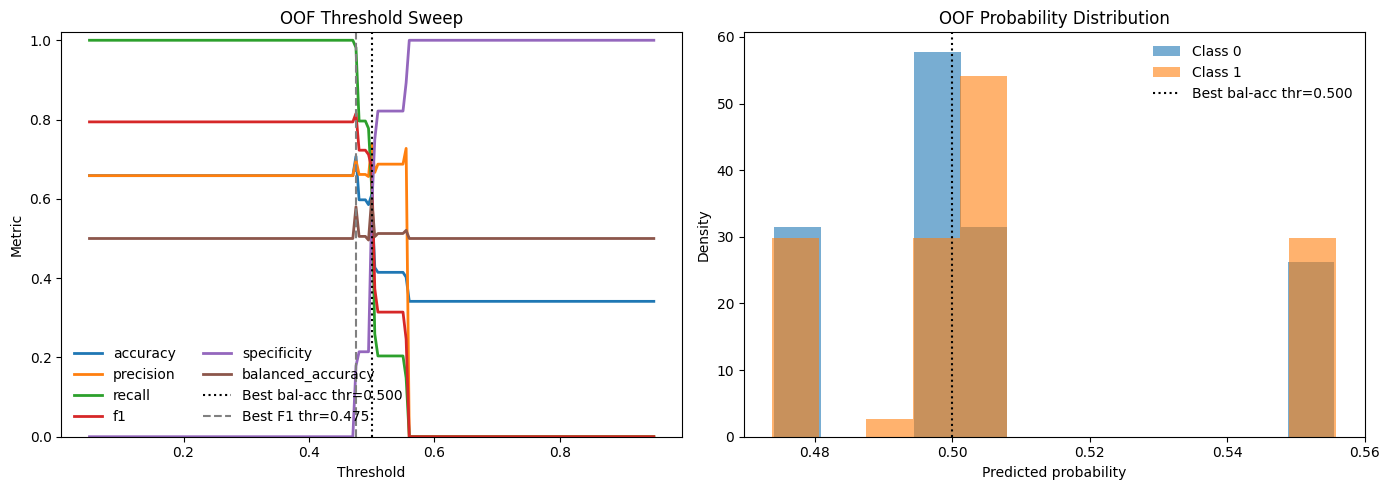

[SAVED] /content/drive/MyDrive/BLiP/out/figure_vae_tuning/validation_threshold_sweep_vae_selected_ld2_cv5_oof.png
Best threshold by balanced accuracy: 0.49999999999999994
Best threshold by F1: 0.4749999999999999


,threshold,accuracy,precision,recall,f1,specificity,balanced_accuracy,tn,fp,fn,tp
90,0.500,0.609756,0.739130,0.629630,0.680000,0.571429,0.600529,16,12,20,34
85,0.475,0.707317,0.697368,0.981481,0.815385,0.178571,0.580026,5,23,1,53
101,0.555,0.402439,0.727273,0.148148,0.246154,0.892857,0.520503,25,3,46,8
97,0.535,0.414634,0.687500,0.203704,0.314286,0.821429,0.512566,23,5,43,11
93,0.515,0.414634,0.687500,0.203704,0.314286,0.821429,0.512566,23,5,43,11
96,0.530,0.414634,0.687500,0.203704,0.314286,0.821429,0.512566,23,5,43,11
95,0.525,0.414634,0.687500,0.203704,0.314286,0.821429,0.512566,23,5,43,11
94,0.520,0.414634,0.687500,0.203704,0.314286,0.821429,0.512566,23,5,43,11
92,0.510,0.414634,0.687500,0.203704,0.314286,0.821429,0.512566,23,5,43,11
99,0.545,0.414634,0.687500,0.203704,0.314286,0.821429,0.512566,23,5,43,11


In [13]:
# Cell 4.2) OOF threshold sweep (CV5 version)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# -------------------------
# Safe defaults
# -------------------------
if "FIG_DIR" not in globals():
    FIG_DIR = Path.cwd() / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

if "MODEL_TAG" not in globals():
    MODEL_TAG = f"{MODEL_VARIANT}_{INPUT_SOURCE}_ld{LATENT_DIM}"

def threshold_sweep_table(y_true, proba):
    rows = []
    thresholds = np.linspace(0.05, 0.95, 181)

    y_true = np.asarray(y_true).astype(int).ravel()
    proba = np.asarray(proba).astype(float).ravel()

    for thr in thresholds:
        pred = (proba >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()

        acc = accuracy_score(y_true, pred)
        prec = precision_score(y_true, pred, zero_division=0)
        rec = recall_score(y_true, pred, zero_division=0)
        f1 = f1_score(y_true, pred, zero_division=0)
        spec = tn / max(tn + fp, 1)
        bal_acc = 0.5 * (rec + spec)

        rows.append({
            "threshold": float(thr),
            "accuracy": float(acc),
            "precision": float(prec),
            "recall": float(rec),
            "f1": float(f1),
            "specificity": float(spec),
            "balanced_accuracy": float(bal_acc),
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
        })

    return pd.DataFrame(rows)

def plot_validation_threshold_sweep(y_true, proba, save_dir=FIG_DIR, tag="val"):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    df_thr = threshold_sweep_table(y_true, proba)

    best_bal_idx = df_thr["balanced_accuracy"].idxmax()
    best_f1_idx = df_thr["f1"].idxmax()

    best_bal_thr = float(df_thr.loc[best_bal_idx, "threshold"])
    best_f1_thr = float(df_thr.loc[best_f1_idx, "threshold"])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # (A) Metrics vs threshold
    for col in ["accuracy", "precision", "recall", "f1", "specificity", "balanced_accuracy"]:
        axes[0].plot(df_thr["threshold"], df_thr[col], lw=2.0, label=col)

    axes[0].axvline(
        best_bal_thr,
        ls=":",
        lw=1.5,
        color="black",
        label=f"Best bal-acc thr={best_bal_thr:.3f}",
    )
    axes[0].axvline(
        best_f1_thr,
        ls="--",
        lw=1.5,
        color="gray",
        label=f"Best F1 thr={best_f1_thr:.3f}",
    )
    axes[0].set_title("OOF Threshold Sweep")
    axes[0].set_xlabel("Threshold")
    axes[0].set_ylabel("Metric")
    axes[0].set_ylim(0, 1.02)
    axes[0].legend(frameon=False, ncol=2)

    # (B) Probability distribution by class
    y_true = np.asarray(y_true).astype(int).ravel()
    proba = np.asarray(proba).astype(float).ravel()

    axes[1].hist(proba[y_true == 0], bins=12, alpha=0.6, density=True, label="Class 0")
    axes[1].hist(proba[y_true == 1], bins=12, alpha=0.6, density=True, label="Class 1")
    axes[1].axvline(
        best_bal_thr,
        ls=":",
        lw=1.5,
        color="black",
        label=f"Best bal-acc thr={best_bal_thr:.3f}",
    )
    axes[1].set_title("OOF Probability Distribution")
    axes[1].set_xlabel("Predicted probability")
    axes[1].set_ylabel("Density")
    axes[1].legend(frameon=False)

    fig.tight_layout()
    out_path = save_dir / f"validation_threshold_sweep_{tag}.png"
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"[SAVED] {out_path}")

    return df_thr, best_bal_thr, best_f1_thr

OOF_TAG = f"{MODEL_TAG}_cv{CV_FOLDS}_oof"

df_thr, best_bal_thr, best_f1_thr = plot_validation_threshold_sweep(
    oof_y,
    oof_proba,
    tag=OOF_TAG,
)

print("Best threshold by balanced accuracy:", best_bal_thr)
print("Best threshold by F1:", best_f1_thr)

display(df_thr.sort_values("balanced_accuracy", ascending=False).head(10))

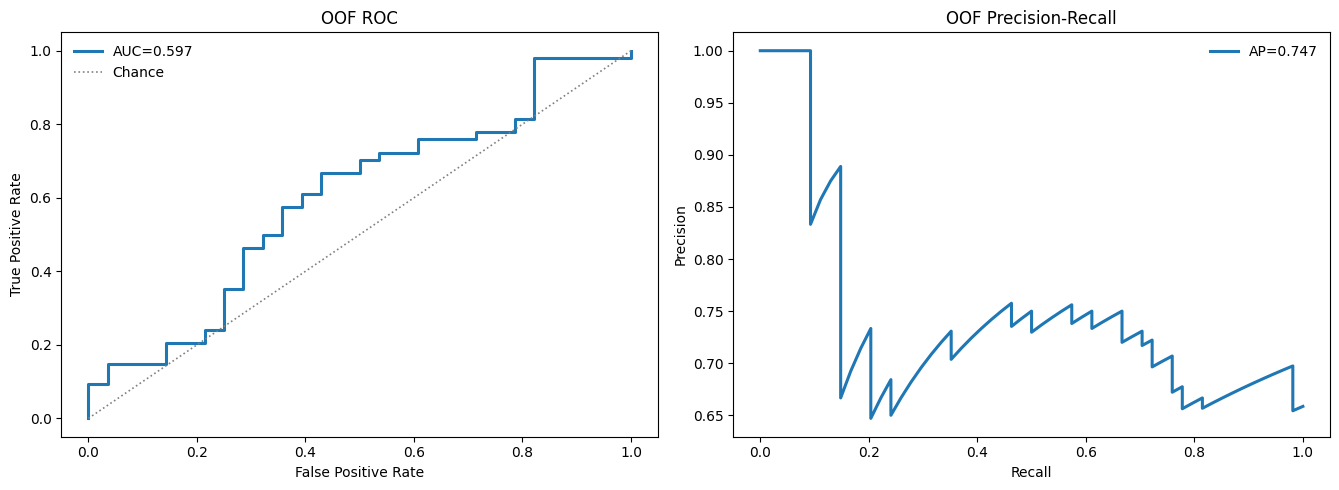

[SAVED] /content/drive/MyDrive/BLiP/out/figure_vae_tuning/validation_roc_pr_vae_selected_ld2_cv5_oof.png


In [14]:
# Cell 4.3) OOF ROC + PR curves (CV5 version)

import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
)

def plot_validation_roc_pr(y_true, proba, save_dir=FIG_DIR, tag="val"):
    auc = roc_auc_score(y_true, proba)
    fpr, tpr, _ = roc_curve(y_true, proba)

    precision, recall, _ = precision_recall_curve(y_true, proba)
    ap = average_precision_score(y_true, proba)

    fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))

    # ROC
    axes[0].plot(fpr, tpr, lw=2.2, label=f"AUC={auc:.3f}")
    axes[0].plot([0, 1], [0, 1], ls=":", lw=1.2, color="gray", label="Chance")
    axes[0].set_title("OOF ROC")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].legend(frameon=False)

    # PR
    axes[1].plot(recall, precision, lw=2.2, label=f"AP={ap:.3f}")
    axes[1].set_title("OOF Precision-Recall")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].legend(frameon=False)

    fig.tight_layout()
    out_path = save_dir / f"validation_roc_pr_{tag}.png"
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"[SAVED] {out_path}")

plot_validation_roc_pr(oof_y, oof_proba, tag=OOF_TAG)

In [15]:
# Cell 5) Final retraining on full train + final evaluation + optional RF on latent mu
# CV-safe version

import copy
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint

# -------------------------
# Final training settings
# -------------------------
FINAL_THRESHOLD_MODE = "balanced_accuracy"   # "balanced_accuracy" or "f1"
FINAL_EPOCH_MODE = "median"                  # "median", "mean", "best_fold", or int

# -------------------------
# Decide final threshold from OOF
# -------------------------
if FINAL_THRESHOLD_MODE == "balanced_accuracy":
    if "best_bal_thr" not in globals():
        raise ValueError("best_bal_thr is not defined. Run Cell 4.2 first.")
    final_thr = float(best_bal_thr)
elif FINAL_THRESHOLD_MODE == "f1":
    if "best_f1_thr" not in globals():
        raise ValueError("best_f1_thr is not defined. Run Cell 4.2 first.")
    final_thr = float(best_f1_thr)
else:
    raise ValueError("FINAL_THRESHOLD_MODE must be 'balanced_accuracy' or 'f1'.")

# -------------------------
# Decide final number of epochs from CV
# -------------------------
if isinstance(FINAL_EPOCH_MODE, int):
    final_epochs = int(FINAL_EPOCH_MODE)
else:
    if "cv_df" not in globals():
        raise ValueError("cv_df is not defined. Run Cell 4 first.")

    if FINAL_EPOCH_MODE == "median":
        final_epochs = int(round(float(cv_df["best_epoch"].median())))
    elif FINAL_EPOCH_MODE == "mean":
        final_epochs = int(round(float(cv_df["best_epoch"].mean())))
    elif FINAL_EPOCH_MODE == "best_fold":
        best_row = cv_df.sort_values("best_val_auc", ascending=False).iloc[0]
        final_epochs = int(best_row["best_epoch"])
    else:
        raise ValueError("FINAL_EPOCH_MODE must be 'median', 'mean', 'best_fold', or an int.")

final_epochs = max(1, final_epochs)

print("Final threshold mode :", FINAL_THRESHOLD_MODE)
print("Final threshold      :", final_thr)
print("Final epoch mode     :", FINAL_EPOCH_MODE)
print("Final epochs         :", final_epochs)

# -------------------------
# Build FINAL input from full train only
# scaler: fit on full train
# SVM-L1 selection: fit on full train only
# -------------------------
X_final_train, _, X_final_test, final_prep_info = prepare_input_split(
    X_tr_raw=X_train_raw,
    y_tr=y_train_np,
    X_val_raw=None,
    X_test_raw=X_test_raw,
    input_source=INPUT_SOURCE,
    use_standardize=USE_STANDARDIZE,
    C=SVM_FS_C,
    max_features=SVM_FS_MAX_FEATURES,
)

final_input_dim = X_final_train.shape[1]
final_hidden_dims = auto_hidden_dims(final_input_dim)

print("\nFinal input source   :", INPUT_SOURCE)
print("Final train shape    :", X_final_train.shape)
print("Final test shape     :", X_final_test.shape)
print("Final input dim      :", final_input_dim)
print("Final hidden dims    :", final_hidden_dims)

if final_prep_info["selected_idx"] is not None:
    print("Selected features    :", len(final_prep_info["selected_idx"]))
    if final_prep_info["input_feature_names"] is not None:
        print("First selected feats :", final_prep_info["input_feature_names"][:10])

# optional: keep for later inspection
final_selected_idx = final_prep_info["selected_idx"]
final_input_feature_names = final_prep_info["input_feature_names"]

# -------------------------
# Build full-train loader and pos_weight
# -------------------------
train_full_ds = TensorDataset(
    torch.from_numpy(X_final_train).float(),
    torch.from_numpy(y_train_np).float(),
)

train_full_loader = DataLoader(
    train_full_ds,
    batch_size=min(BATCH_SIZE, len(train_full_ds)),
    shuffle=True,
)

n_pos_full = int((y_train_np == 1).sum())
n_neg_full = int((y_train_np == 0).sum())
pos_weight_full = torch.tensor(
    [n_neg_full / max(n_pos_full, 1)],
    dtype=torch.float32,
    device=DEVICE,
)

# -------------------------
# Train final model on full training set
# -------------------------
seed_everything(4242)

final_model = SupervisedVAE(
    input_dim=final_input_dim,
    hidden_dims=final_hidden_dims,
    latent_dim=LATENT_DIM,
    dropout=DROPOUT,
).to(DEVICE)

final_optimizer = torch.optim.AdamW(
    final_model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

final_history = []

for epoch in range(1, final_epochs + 1):
    final_model.train()

    epoch_total = 0.0
    epoch_recon = 0.0
    epoch_kl = 0.0
    epoch_cls = 0.0
    epoch_tc = 0.0
    epoch_n = 0

    for xb, yb in train_full_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        final_optimizer.zero_grad()

        out = final_model(xb)
        loss_dict = compute_loss_dict(out, xb, yb, pos_weight=pos_weight_full)

        loss_dict["total"].backward()
        nn.utils.clip_grad_norm_(final_model.parameters(), GRAD_CLIP_NORM)
        final_optimizer.step()

        bs = xb.size(0)
        epoch_total += loss_dict["total"].item() * bs
        epoch_recon += loss_dict["recon"].item() * bs
        epoch_kl += loss_dict["kl"].item() * bs
        epoch_cls += loss_dict["cls"].item() * bs
        epoch_tc += loss_dict["tc"].item() * bs
        epoch_n += bs

    train_pred_epoch = predict_model(final_model, X_final_train)
    train_auc_epoch = roc_auc_score(y_train_np, train_pred_epoch["proba"])

    epoch_row = {
        "epoch": epoch,
        "train_total": epoch_total / epoch_n,
        "train_recon": epoch_recon / epoch_n,
        "train_kl": epoch_kl / epoch_n,
        "train_cls": epoch_cls / epoch_n,
        "train_tc": epoch_tc / epoch_n,
        "train_auc": train_auc_epoch,
    }
    final_history.append(epoch_row)

    if epoch == 1 or epoch % 10 == 0 or epoch == final_epochs:
        print(
            f"[Final train | Epoch {epoch:03d}] "
            f"train_total={epoch_row['train_total']:.4f} | "
            f"train_auc={train_auc_epoch:.4f}"
        )

final_history_df = pd.DataFrame(final_history)

# -------------------------
# Final direct supervised VAE / beta-TCVAE head evaluation
# -------------------------
train_pred_full = predict_model(final_model, X_final_train)
test_pred = predict_model(final_model, X_final_test)

train_metrics = evaluate_predictions(y_train_np, train_pred_full["proba"], threshold=final_thr)
test_metrics = evaluate_predictions(y_test_np, test_pred["proba"], threshold=final_thr)

print("\n=== Direct supervised VAE / beta-TCVAE head ===")
print("Threshold used :", final_thr)
print("Train AUC      :", train_metrics["auc"])
print("Train ACC      :", train_metrics["acc"])
print("Test  AUC      :", test_metrics["auc"])
print("Test  ACC      :", test_metrics["acc"])

print("\nTrain confusion matrix:")
print(train_metrics["cm"])
print("\nTest confusion matrix:")
print(test_metrics["cm"])

print("\nTest classification report:")
print(test_metrics["report"])

# -------------------------
# Latent extraction
# -------------------------
Z_train_mu = train_pred_full["mu"]
Z_test_mu = test_pred["mu"]

print("\nLatent train shape:", Z_train_mu.shape)
print("Latent test shape :", Z_test_mu.shape)

# -------------------------
# Optional RF on latent mu
# -------------------------
if RUN_RF_ON_LATENT:
    print("\n=== RF on latent mu ===")

    cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=2042)

    PARAM_DIST = {
        "n_estimators": randint(100, 650),
        "max_depth": [None, 8, 12],
        "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
        "min_samples_split": randint(2, 20),
        "min_samples_leaf": randint(1, 8),
        "bootstrap": [True],
        "max_samples": [None, 0.6, 0.8, 1.0],
        "class_weight": [None, "balanced"],
        "criterion": ["gini", "entropy"],
    }

    rs_latent = RandomizedSearchCV(
        estimator=RandomForestClassifier(random_state=2042, n_jobs=-1),
        param_distributions=PARAM_DIST,
        n_iter=5,
        scoring="roc_auc",
        cv=cv5,
        n_jobs=-1,
        random_state=2042,
        verbose=0,
    )
    rs_latent.fit(Z_train_mu, y_train_np)

    best_params_latent = dict(rs_latent.best_params_)
    best_params_latent.pop("random_state", None)
    best_params_latent.pop("n_jobs", None)
    if best_params_latent.get("bootstrap") is False:
        best_params_latent.pop("max_samples", None)

    print("[Latent RF] best CV AUC:", rs_latent.best_score_)
    print("[Latent RF] best params:", best_params_latent)

    rf_latent = RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        **best_params_latent,
    )
    rf_latent.fit(Z_train_mu, y_train_np)

    train_proba_latent = rf_latent.predict_proba(Z_train_mu)[:, 1]
    test_proba_latent = rf_latent.predict_proba(Z_test_mu)[:, 1]

    train_metrics_latent = evaluate_predictions(
        y_train_np,
        train_proba_latent,
        threshold=final_thr,
    )
    test_metrics_latent = evaluate_predictions(
        y_test_np,
        test_proba_latent,
        threshold=final_thr,
    )

    print("\n[Latent RF] Threshold :", final_thr)
    print("[Latent RF] Train AUC :", train_metrics_latent["auc"])
    print("[Latent RF] Train ACC :", train_metrics_latent["acc"])
    print("[Latent RF] Test  AUC :", test_metrics_latent["auc"])
    print("[Latent RF] Test  ACC :", test_metrics_latent["acc"])
    print("\n[Latent RF] Test confusion matrix:")
    print(test_metrics_latent["cm"])
    print("\n[Latent RF] Test classification report:")
    print(test_metrics_latent["report"])

Final threshold mode : balanced_accuracy
Final threshold      : 0.49999999999999994
Final epoch mode     : median
Final epochs         : 9

Final input source   : selected
Final train shape    : (82, 53)
Final test shape     : (36, 53)
Final input dim      : 53
Final hidden dims    : [8, 4]
Selected features    : 53
First selected feats : ['INTENSITY_STD_NET_T2', 'INTENSITY_Mean_ED_T1Gd', 'INTENSITY_STD_ED_T1', 'INTENSITY_Mean_ED_T2', 'INTENSITY_STD_ED_FLAIR', 'HISTO_ET_T1_Bin8', 'HISTO_ED_T1_Bin1', 'HISTO_ED_T1_Bin6', 'HISTO_ED_T1_Bin7', 'HISTO_NET_T1_Bin9']
[Final train | Epoch 001] train_total=2.9601 | train_auc=0.7540
[Final train | Epoch 009] train_total=2.4989 | train_auc=0.7030

=== Direct supervised VAE / beta-TCVAE head ===
Threshold used : 0.49999999999999994
Train AUC      : 0.703042328042328
Train ACC      : 0.6585365853658537
Test  AUC      : 0.6284722222222223
Test  ACC      : 0.6666666666666666

Train confusion matrix:
[[ 0 28]
 [ 0 54]]

Test confusion matrix:
[[ 0 12]


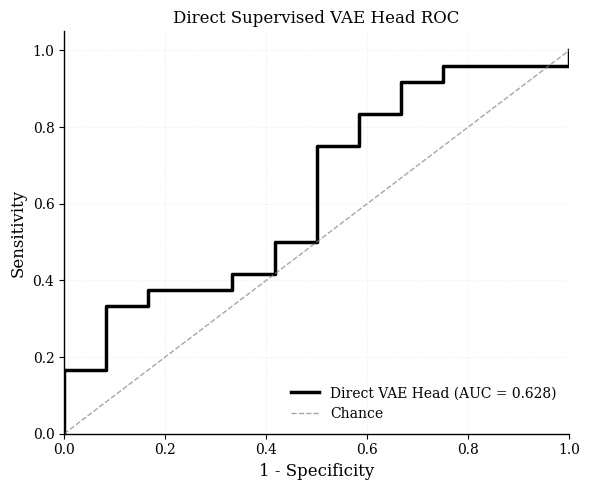

[SAVED] /content/drive/MyDrive/BLiP/out/VAE_ROC_Plots/Figure_ROC_DirectVAEHead.png
[INFO] Direct VAE Head test AUC = 0.628


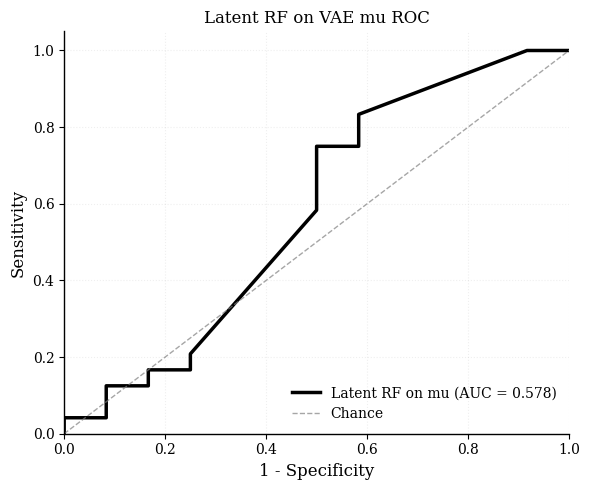

[SAVED] /content/drive/MyDrive/BLiP/out/VAE_ROC_Plots/Figure_ROC_LatentRF.png
[INFO] Latent RF on mu test AUC = 0.578


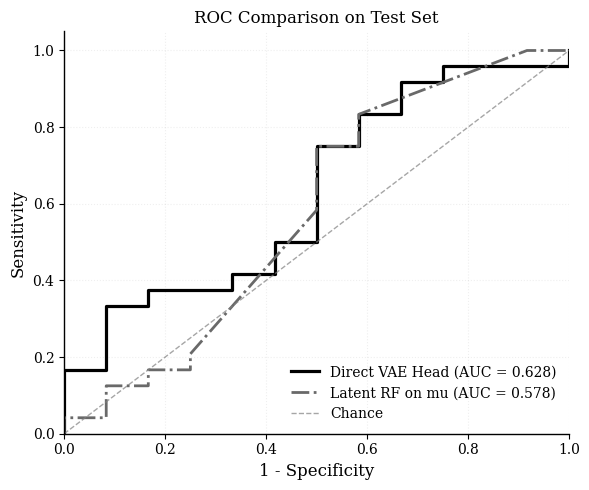

[SAVED] /content/drive/MyDrive/BLiP/out/VAE_ROC_Plots/Figure_ROC_Comparison_VAE_vs_LatentRF.png


In [16]:
# Cell 5.1) Paper-style ROC plots for Direct VAE head and Latent RF

import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

# ---------------------------------------------------------
# 1. 저장 폴더 및 스타일 설정
# ---------------------------------------------------------

plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.linewidth"] = 1.0

# ---------------------------------------------------------
# 2. 필요한 변수 체크
# ---------------------------------------------------------
if "y_test_np" not in globals():
    raise ValueError("y_test_np is not defined. Run the previous evaluation cells first.")

if "test_pred" not in globals():
    raise ValueError("test_pred is not defined. Run Cell 5 first.")

if "Z_test_mu" not in globals():
    raise ValueError("Z_test_mu is not defined. Run Cell 5 first.")

if "rf_latent" not in globals():
    raise ValueError("rf_latent is not defined. Run Cell 5 with RUN_RF_ON_LATENT=True first.")

# ---------------------------------------------------------
# 3. 테스트 확률 준비
# ---------------------------------------------------------
yte = np.asarray(y_test_np).ravel().astype(int)

# Direct supervised VAE head
prob_te_vae = np.asarray(test_pred["proba"]).ravel().astype(float)

# Latent RF
prob_te_latent = rf_latent.predict_proba(Z_test_mu)[:, 1]

# ---------------------------------------------------------
# 4. 공통 ROC plot 함수
# ---------------------------------------------------------
def plot_clean_roc(
    y_true,
    proba,
    title,
    curve_label,
    filename,
    save_folder,
):
    auc = float(roc_auc_score(y_true, proba))
    fpr, tpr, _ = roc_curve(y_true, proba)

    plt.figure(figsize=(6, 5))

    # 메인 ROC 곡선
    plt.plot(
        fpr,
        tpr,
        lw=2.5,
        color="black",
        label=f"{curve_label} (AUC = {auc:.3f})"
    )

    # Chance line
    plt.plot(
        [0, 1], [0, 1],
        color="gray",
        lw=1.0,
        ls="--",
        alpha=0.7,
        label="Chance"
    )

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])

    plt.xlabel("1 - Specificity", fontsize=12)
    plt.ylabel("Sensitivity", fontsize=12)
    plt.title(title, fontsize=12)

    plt.legend(loc="lower right", fontsize=10, frameon=False)
    plt.grid(alpha=0.2, ls=":")

    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    save_path = os.path.join(save_folder, filename)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"[SAVED] {save_path}")
    print(f"[INFO] {curve_label} test AUC = {auc:.3f}")

    return {
        "auc": auc,
        "fpr": fpr,
        "tpr": tpr,
        "save_path": save_path,
    }

# ---------------------------------------------------------
# 5. Direct VAE head ROC
# ---------------------------------------------------------
vae_roc = plot_clean_roc(
    y_true=yte,
    proba=prob_te_vae,
    title="Direct Supervised VAE Head ROC",
    curve_label="Direct VAE Head",
    filename="Figure_ROC_DirectVAEHead.png",
    save_folder=save_folder,
)

# ---------------------------------------------------------
# 6. Latent RF ROC
# ---------------------------------------------------------
latent_rf_roc = plot_clean_roc(
    y_true=yte,
    proba=prob_te_latent,
    title="Latent RF on VAE mu ROC",
    curve_label="Latent RF on mu",
    filename="Figure_ROC_LatentRF.png",
    save_folder=save_folder,
)

# ---------------------------------------------------------
# 7. 비교용 combined ROC
# ---------------------------------------------------------
plt.figure(figsize=(6, 5))

plt.plot(
    vae_roc["fpr"],
    vae_roc["tpr"],
    lw=2.3,
    color="black",
    label=f"Direct VAE Head (AUC = {vae_roc['auc']:.3f})"
)

plt.plot(
    latent_rf_roc["fpr"],
    latent_rf_roc["tpr"],
    lw=2.0,
    color="dimgray",
    ls="-.",
    label=f"Latent RF on mu (AUC = {latent_rf_roc['auc']:.3f})"
)

plt.plot(
    [0, 1], [0, 1],
    color="gray",
    lw=1.0,
    ls="--",
    alpha=0.7,
    label="Chance"
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel("1 - Specificity", fontsize=12)
plt.ylabel("Sensitivity", fontsize=12)
plt.title("ROC Comparison on Test Set", fontsize=12)

plt.legend(loc="lower right", fontsize=10, frameon=False)
plt.grid(alpha=0.2, ls=":")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

combined_path = os.path.join(save_folder, "Figure_ROC_Comparison_VAE_vs_LatentRF.png")
plt.savefig(combined_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"[SAVED] {combined_path}")

=== Starting VAE Hyperparameter Tuning (Total 16 configs) ===

[*] Testing Config -> LATENT_DIM: 2 | BETA: 0.5
[Fold 1 | Epoch 001] train_total=2.6435 | train_auc=0.4514 | val_auc=0.3788
[Fold 1 | Epoch 010] train_total=2.4977 | train_auc=0.9598 | val_auc=0.3939
[Fold 1 | Epoch 020] train_total=2.3829 | train_auc=1.0000 | val_auc=0.5455
[Fold 2 | Epoch 001] train_total=2.7151 | train_auc=0.6152 | val_auc=0.7727
[Fold 2 | Epoch 010] train_total=2.4866 | train_auc=0.7770 | val_auc=0.6667
[Fold 2 | Epoch 020] train_total=2.4752 | train_auc=0.8647 | val_auc=0.6818
[Fold 3 | Epoch 001] train_total=2.7297 | train_auc=0.4348 | val_auc=0.4364
[Fold 3 | Epoch 010] train_total=2.5021 | train_auc=0.6724 | val_auc=0.4727
[Fold 3 | Epoch 020] train_total=2.4981 | train_auc=0.9403 | val_auc=0.5818
[Fold 4 | Epoch 001] train_total=2.6930 | train_auc=0.7184 | val_auc=0.6727
[Fold 4 | Epoch 010] train_total=2.4636 | train_auc=0.9990 | val_auc=0.6727
[Fold 4 | Epoch 020] train_total=2.2506 | train_auc=1

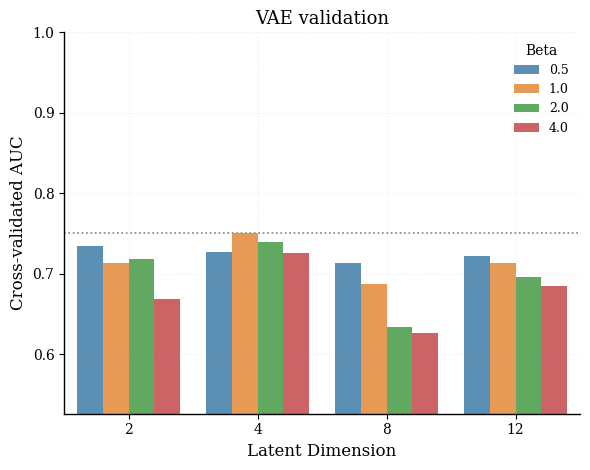


[SAVED] /content/drive/MyDrive/BLiP/out/VAE_ROC_Plots/Figure_VAE_CV_summary.png
[*] 최적 파라미터로 전역 변수 업데이트 완료: LATENT_DIM=4, BETA=1.0


In [17]:
import os
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold

# =========================================================
# 1. 튜닝할 하이퍼파라미터 그리드
# =========================================================
tune_latent_dims = [2, 4, 8, 12]
tune_betas = [0.5, 1.0, 2.0, 4.0]

tuning_results = []
CV_FOLDS = 5
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)

print(f"=== Starting VAE Hyperparameter Tuning (Total {len(tune_latent_dims) * len(tune_betas)} configs) ===")

# =========================================================
# 2. 튜닝 루프: 기존 함수 호출
# =========================================================
for ld, b in itertools.product(tune_latent_dims, tune_betas):
    print(f"\n" + "="*50)
    print(f"[*] Testing Config -> LATENT_DIM: {ld} | BETA: {b}")
    print("="*50)

    # 전역 변수 덮어쓰기
    global LATENT_DIM, BETA
    LATENT_DIM = ld
    BETA = b

    fold_val_aucs = []

    for fold_id, (tr_idx, val_idx) in enumerate(skf.split(X_train_raw, y_train_np), start=1):
        X_tr_raw_fold = X_train_raw[tr_idx]
        X_val_raw_fold = X_train_raw[val_idx]
        y_tr = y_train_np[tr_idx]
        y_val = y_train_np[val_idx]

        # Input Split
        X_tr, X_val, _, prep_info = prepare_input_split(
            X_tr_raw=X_tr_raw_fold,
            y_tr=y_tr,
            X_val_raw=X_val_raw_fold,
            X_test_raw=None,
            input_source=INPUT_SOURCE,
            use_standardize=True,
            C=SVM_FS_C,
            max_features=SVM_FS_MAX_FEATURES,
        )

        # Fold 학습
        fold_out = train_one_fold(X_tr, y_tr, X_val, y_val, fold_id=fold_id)
        fold_val_aucs.append(fold_out["best_val_auc"])

    mean_auc = np.mean(fold_val_aucs)
    std_auc = np.std(fold_val_aucs, ddof=1)

    print(f"\n[Result] LATENT_DIM={ld}, BETA={b} ==> Mean Val AUC: {mean_auc:.4f} ± {std_auc:.4f}")

    tuning_results.append({
        "latent_dim": ld,
        "beta": b,
        "mean_val_auc": mean_auc,
        "std_val_auc": std_auc
    })

# =========================================================
# 3. 튜닝 결과 정리 및 Paper-style 시각화
# =========================================================
df_tuning = pd.DataFrame(tuning_results)

# --- 스타일 세팅 (PCA/LDA 코드와 완벽히 동일하게) ---
plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.linewidth"] = 1.0

fig, ax = plt.subplots(figsize=(6, 4.8))

# seaborn 테마를 쓰지 않고 barplot만 활용하여 색상(기본 파스텔/tab10) 유지
sns.barplot(
    data=df_tuning,
    x="latent_dim",
    y="mean_val_auc",
    hue="beta",
    capsize=0.1,
    err_kws={'linewidth': 1.2},
    ax=ax,
    alpha=0.8,
    palette="tab10" # matplotlib 기본 컬러(파랑/주황/초록) 매칭
)

# 최고 AUC 강조 라인 (PCA 플롯의 회색 점선 감성)
best_auc = df_tuning["mean_val_auc"].max()
ax.axhline(best_auc, color="gray", ls=":", lw=1.2, zorder=0)

# 텍스트 및 축 설정
ax.set_ylim(max(0.0, df_tuning["mean_val_auc"].min() - 0.1), 1.0)
ax.set_title("VAE validation", fontsize=13)
ax.set_xlabel("Latent Dimension", fontsize=12)
ax.set_ylabel("Cross-validated AUC", fontsize=12)

# 배경 그리드 및 테두리 설정 (준서님 코드 스타일)
ax.grid(alpha=0.2, linestyle=":")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# 범례 깔끔하게
ax.legend(title='Beta', frameon=False, fontsize=9, title_fontsize=10, loc='best')

fig.tight_layout()

# 저장
summary_fig_path = os.path.join(save_folder, "Figure_VAE_CV_summary.png")
fig.savefig(summary_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"\n[SAVED] {summary_fig_path}")

# =========================================================
# 4. 최적 파라미터 글로벌 세팅
# =========================================================
best_config = df_tuning.sort_values(by="mean_val_auc", ascending=False).iloc[0]
LATENT_DIM = int(best_config["latent_dim"])
BETA = float(best_config["beta"])
print(f"[*] 최적 파라미터로 전역 변수 업데이트 완료: LATENT_DIM={LATENT_DIM}, BETA={BETA}")

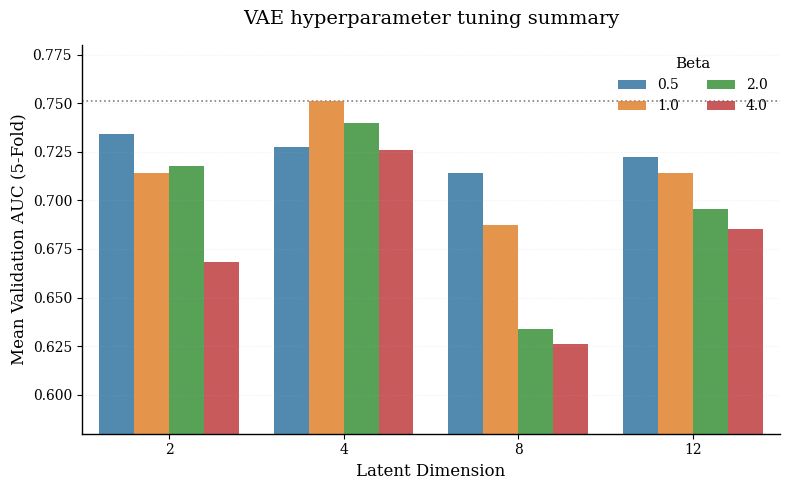


[SAVED] /content/drive/MyDrive/BLiP/out/VAE_ROC_Plots/Figure_VAE_CV_summary.png


In [18]:
# =========================================================
# 3. 튜닝 결과 정리 및 Paper-style 시각화 (Optimized Scale)
# =========================================================
df_tuning = pd.DataFrame(tuning_results)
save_folder = OUT_DIR / "VAE_ROC_Plots"
# --- 스타일 세팅 ---
plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.linewidth"] = 1.0

# 가로 길이는 8로 유지하되, 세로 여백을 줄이기 위해 조절
fig, ax = plt.subplots(figsize=(8, 5))

# barplot 생성
sns.barplot(
    data=df_tuning,
    x="latent_dim",
    y="mean_val_auc",
    hue="beta",
    capsize=0.05,
    err_kws={'linewidth': 1.0},
    ax=ax,
    alpha=0.85,
    palette="tab10"
)

# 최고 AUC 강조 라인
best_auc = df_tuning["mean_val_auc"].max()
ax.axhline(best_auc, color="gray", ls=":", lw=1.2, zorder=0)

# ---------------------------------------------------------
# 핵심: Y축 범위를 데이터 밀집 지역으로 타이트하게 설정
# ---------------------------------------------------------
# 데이터의 최소값보다 살짝 낮게, 최대값보다 살짝 높게 잡습니다.
ymin = 0.58  # 0.6보다 조금 아래
ymax = 0.78  # 0.75보다 조금 위 (범례 공간 확보)
ax.set_ylim(ymin, ymax)

# 타이틀 및 라벨
ax.set_title("VAE hyperparameter tuning summary", fontsize=14, pad=15)
ax.set_xlabel("Latent Dimension", fontsize=12)
ax.set_ylabel("Mean Validation AUC (5-Fold)", fontsize=12)

# 배경 및 테두리
ax.grid(alpha=0.2, linestyle=":", axis='y') # y축 그리드만 강조
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# 범례 위치 조정 (상단 빈 공간으로)
ax.legend(title='Beta', frameon=False, fontsize=10, title_fontsize=11,
          loc='upper right', ncol=2) # ncol=2로 하면 가로로 길어져 공간을 덜 차지함

fig.tight_layout()

# 저장
summary_fig_path = os.path.join(save_folder, "Figure_VAE_CV_summary.png")
fig.savefig(summary_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"\n[SAVED] {summary_fig_path}")

In [19]:
# Cell 6A) Tune PCA+RF and LDA->RF on TRAIN only (CV-safe, end-to-end)

import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

# -------------------------------------------------
# base input
# -------------------------------------------------
Xb_train = np.asarray(X_final_train, dtype=np.float32)
Xb_test  = np.asarray(X_final_test, dtype=np.float32)
ytr = np.asarray(y_train_np).astype(int).ravel()
yte = np.asarray(y_test_np).astype(int).ravel()

print("Base input shape (train):", Xb_train.shape)
print("Base input shape (test) :", Xb_test.shape)

# -------------------------------------------------
# RF params
# -------------------------------------------------
if "best_params_latent" in globals():
    rf_params = dict(best_params_latent)
else:
    rf_params = {
        "n_estimators": 300,
        "max_depth": None,
        "max_features": "sqrt",
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "bootstrap": True,
        "class_weight": "balanced",
        "criterion": "gini",
    }

rf_params.pop("random_state", None)
rf_params.pop("n_jobs", None)

print("RF params used:", rf_params)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# =================================================
# 1) PCA + RF tuning
# =================================================
PCA_CANDIDATES = [2, 3, 5, 8, 10, 12, 15]
PCA_CANDIDATES = [k for k in PCA_CANDIDATES if 1 <= k <= Xb_train.shape[1]]

pca_rows = []

for n_pc in PCA_CANDIDATES:
    pipe = Pipeline([
        ("pca", PCA(n_components=n_pc)),
        ("rf", RandomForestClassifier(
            random_state=42,
            n_jobs=-1,
            **rf_params,
        )),
    ])

    oof_proba = cross_val_predict(
        pipe,
        Xb_train,
        ytr,
        cv=cv,
        method="predict_proba",
        n_jobs=-1,
    )[:, 1]

    pca_rows.append({
        "model": "PCA+RF",
        "n_components": n_pc,
        "cv_auc": roc_auc_score(ytr, oof_proba),
    })

pca_tune_df = pd.DataFrame(pca_rows).sort_values("cv_auc", ascending=False)
display(pca_tune_df)

best_pca_n = int(pca_tune_df.iloc[0]["n_components"])
print("Best PCA n_components:", best_pca_n)

# =================================================
# 2) LDA -> RF tuning
# lsqr 제외: transform() 안 되기 때문
# =================================================
lda_proj_candidates = [
    {"solver": "svd",   "shrinkage": None},
    {"solver": "eigen", "shrinkage": None},
    {"solver": "eigen", "shrinkage": "auto"},
]

lda_rows = []

for cfg in lda_proj_candidates:
    try:
        pipe = Pipeline([
            ("lda", LinearDiscriminantAnalysis(
                n_components=1,
                solver=cfg["solver"],
                shrinkage=cfg["shrinkage"],
            )),
            ("rf", RandomForestClassifier(
                random_state=42,
                n_jobs=-1,
                **rf_params,
            )),
        ])

        oof_proba = cross_val_predict(
            pipe,
            Xb_train,
            ytr,
            cv=cv,
            method="predict_proba",
            n_jobs=-1,
        )[:, 1]

        lda_rows.append({
            "model": "LDA->RF",
            "solver": cfg["solver"],
            "shrinkage": str(cfg["shrinkage"]),
            "cv_auc": roc_auc_score(ytr, oof_proba),
        })
    except Exception:
        lda_rows.append({
            "model": "LDA->RF",
            "solver": cfg["solver"],
            "shrinkage": str(cfg["shrinkage"]),
            "cv_auc": np.nan,
        })

lda_proj_tune_df = pd.DataFrame(lda_rows).sort_values("cv_auc", ascending=False)
display(lda_proj_tune_df)

best_lda_proj_solver = lda_proj_tune_df.iloc[0]["solver"]
best_lda_proj_shrinkage = lda_proj_tune_df.iloc[0]["shrinkage"]

if best_lda_proj_shrinkage == "None":
    best_lda_proj_shrinkage = None
elif best_lda_proj_shrinkage == "auto":
    best_lda_proj_shrinkage = "auto"

print("Best LDA->RF solver   :", best_lda_proj_solver)
print("Best LDA->RF shrinkage:", best_lda_proj_shrinkage)

Base input shape (train): (82, 53)
Base input shape (test) : (36, 53)
RF params used: {'bootstrap': True, 'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'max_samples': 1.0, 'min_samples_leaf': 6, 'min_samples_split': 17, 'n_estimators': 356}


,model,n_components,cv_auc
6,PCA+RF,15,0.789683
5,PCA+RF,12,0.738095
4,PCA+RF,10,0.728836
3,PCA+RF,8,0.723545
1,PCA+RF,3,0.718254
2,PCA+RF,5,0.715608
0,PCA+RF,2,0.654762


Best PCA n_components: 15


,model,solver,shrinkage,cv_auc
2,LDA->RF,eigen,auto,0.911706
0,LDA->RF,svd,None,0.911376
1,LDA->RF,eigen,None,0.911376


Best LDA->RF solver   : eigen
Best LDA->RF shrinkage: auto


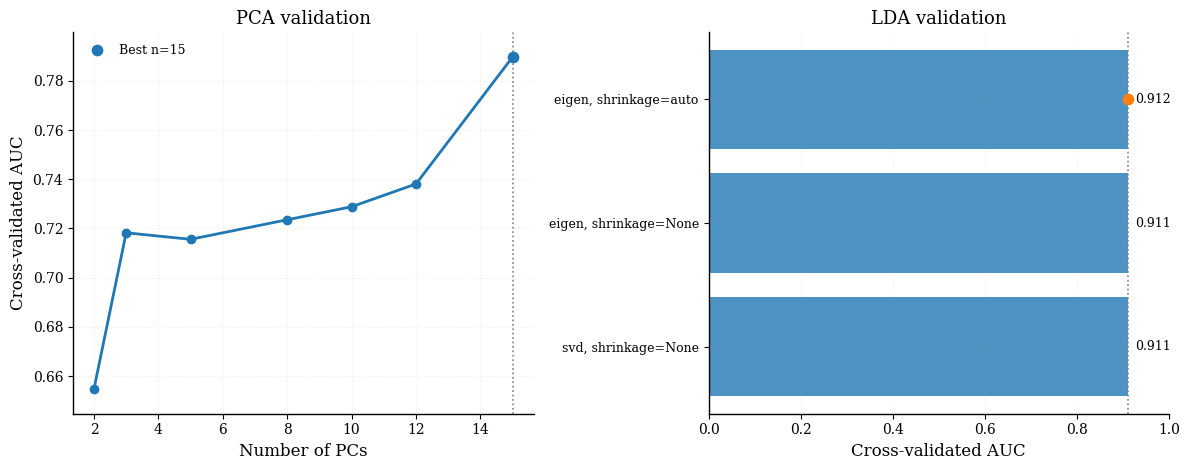

[SAVED] /content/drive/MyDrive/BLiP/out/VAE_ROC_Plots/Figure_PCA_LDA_validation_summary.png


In [20]:
# Cell) Combined validation summary figure
# Left: PCA CV AUC vs n_components
# Right: LDA CV AUC summary across solver / shrinkage
# Saved as one figure

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------
# save folder
# -------------------------------------------------


plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.linewidth"] = 1.0

# -------------------------------------------------
# load tuning results
# expects:
#   pca_tune_df with columns: n_components, cv_auc
#   lda_proj_tune_df or lda_tune_df with columns: solver, shrinkage, cv_auc
# -------------------------------------------------
if "pca_tune_df" not in globals():
    raise ValueError("pca_tune_df is not defined. Run the PCA tuning cell first.")

if "lda_proj_tune_df" in globals():
    lda_plot_df = lda_proj_tune_df.copy()
elif "lda_tune_df" in globals():
    lda_plot_df = lda_tune_df.copy()
else:
    raise ValueError("lda_proj_tune_df or lda_tune_df is not defined. Run the LDA tuning cell first.")

pca_plot_df = pca_tune_df.copy().sort_values("n_components")

# label 만들기
lda_plot_df = lda_plot_df.copy()
lda_plot_df["label"] = (
    lda_plot_df["solver"].astype(str) +
    ", shrinkage=" +
    lda_plot_df["shrinkage"].astype(str)
)

# NaN 제거 후 정렬
lda_plot_df = lda_plot_df.dropna(subset=["cv_auc"]).sort_values("cv_auc", ascending=True)

# -------------------------------------------------
# combined figure
# -------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

# -------------------------
# (A) PCA CV AUC vs n_components
# -------------------------
axes[0].plot(
    pca_plot_df["n_components"],
    pca_plot_df["cv_auc"],
    marker="o",
    lw=2.0,
)

if "best_pca_n" in globals():
    best_row = pca_plot_df.loc[pca_plot_df["n_components"] == best_pca_n]
    if len(best_row) > 0:
        axes[0].axvline(best_pca_n, color="gray", ls=":", lw=1.2)
        axes[0].scatter(
            best_row["n_components"],
            best_row["cv_auc"],
            s=55,
            zorder=3,
            label=f"Best n={best_pca_n}",
        )
        axes[0].legend(frameon=False, fontsize=9, loc="best")

axes[0].set_xlabel("Number of PCs", fontsize=12)
axes[0].set_ylabel("Cross-validated AUC", fontsize=12)
axes[0].set_title("PCA validation", fontsize=13)
axes[0].grid(alpha=0.2, linestyle=":")

# 보기 좋게 약간 여유
pca_ymin = max(0.0, pca_plot_df["cv_auc"].min() - 0.01)
pca_ymax = min(1.0, pca_plot_df["cv_auc"].max() + 0.01)
axes[0].set_ylim(pca_ymin, pca_ymax)

# -------------------------
# (B) LDA CV AUC summary
# -------------------------
ypos = np.arange(len(lda_plot_df))

axes[1].barh(
    ypos,
    lda_plot_df["cv_auc"].values,
    alpha=0.8,
)

axes[1].set_yticks(ypos)
axes[1].set_yticklabels(lda_plot_df["label"].values, fontsize=9)
axes[1].set_xlabel("Cross-validated AUC", fontsize=12)
axes[1].set_title("LDA validation", fontsize=13)
axes[1].grid(alpha=0.2, linestyle=":")

# 핵심: 오른쪽 축을 1.0까지 고정
axes[1].set_xlim(0.0, 1.0)

# best LDA 강조
best_lda_idx = lda_plot_df["cv_auc"].idxmax()
best_lda_row = lda_plot_df.loc[best_lda_idx]
best_lda_pos = np.where(lda_plot_df.index == best_lda_idx)[0][0]

axes[1].axvline(best_lda_row["cv_auc"], color="gray", ls=":", lw=1.2)
axes[1].scatter(
    [best_lda_row["cv_auc"]],
    [best_lda_pos],
    s=55,
    zorder=3,
)

# 원하면 값도 같이 표시
for i, auc_val in enumerate(lda_plot_df["cv_auc"].values):
    axes[1].text(
        min(auc_val + 0.015, 0.98),
        i,
        f"{auc_val:.3f}",
        va="center",
        fontsize=9,
    )

# paper-style spines
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.tight_layout()

out_path = os.path.join(save_folder, "Figure_PCA_LDA_validation_summary.png")
fig.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"[SAVED] {out_path}")

In [21]:
# Cell 6B) Refit tuned PCA+RF and tuned LDA->RF on full train

import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, classification_report

# -------------------------------------------------
# base input
# -------------------------------------------------
Xb_train = np.asarray(X_final_train, dtype=np.float32)
Xb_test  = np.asarray(X_final_test, dtype=np.float32)
ytr = np.asarray(y_train_np).astype(int).ravel()
yte = np.asarray(y_test_np).astype(int).ravel()

print("Chosen PCA n_components:", best_pca_n)
print("Chosen LDA->RF solver   :", best_lda_proj_solver)
print("Chosen LDA->RF shrinkage:", best_lda_proj_shrinkage)

# =================================================
# 1) PCA -> RF
# =================================================
pca_full = PCA(n_components=best_pca_n)
Zp_train = pca_full.fit_transform(Xb_train)
Zp_test  = pca_full.transform(Xb_test)

pca_2d = PCA(n_components=2)
Zp_train_2d = pca_2d.fit_transform(Xb_train)

rf_pca = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    **rf_params,
)
rf_pca.fit(Zp_train, ytr)

pca_train_proba = rf_pca.predict_proba(Zp_train)[:, 1]
pca_test_proba  = rf_pca.predict_proba(Zp_test)[:, 1]
pca_test_pred   = (pca_test_proba >= final_thr).astype(int)

print("\n=== PCA + RF baseline ===")
print("Train AUC:", roc_auc_score(ytr, pca_train_proba))
print("Test  AUC:", roc_auc_score(yte, pca_test_proba))
print("Test  ACC:", accuracy_score(yte, pca_test_pred))
print("Test confusion matrix:\n", confusion_matrix(yte, pca_test_pred))
print(classification_report(yte, pca_test_pred, digits=4))

# =================================================
# 2) LDA -> RF
# =================================================
lda_proj = LinearDiscriminantAnalysis(
    n_components=1,
    solver=best_lda_proj_solver,
    shrinkage=best_lda_proj_shrinkage,
)

Zl_train = lda_proj.fit_transform(Xb_train, ytr)
Zl_test  = lda_proj.transform(Xb_test)

rf_lda = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    **rf_params,
)
rf_lda.fit(Zl_train, ytr)

lda_train_proba = rf_lda.predict_proba(Zl_train)[:, 1]
lda_test_proba  = rf_lda.predict_proba(Zl_test)[:, 1]
lda_test_pred   = (lda_test_proba >= final_thr).astype(int)

print("\n=== LDA -> RF baseline ===")
print("Train AUC:", roc_auc_score(ytr, lda_train_proba))
print("Test  AUC:", roc_auc_score(yte, lda_test_proba))
print("Test  ACC:", accuracy_score(yte, lda_test_pred))
print("Test confusion matrix:\n", confusion_matrix(yte, lda_test_pred))
print(classification_report(yte, lda_test_pred, digits=4))

# =================================================
# 3) summary table
# =================================================
baseline_df = pd.DataFrame([
    {
        "model": f"PCA({best_pca_n}) + RF",
        "train_auc": roc_auc_score(ytr, pca_train_proba),
        "test_auc": roc_auc_score(yte, pca_test_proba),
        "test_acc": accuracy_score(yte, pca_test_pred),
    },
    {
        "model": f"LDA({best_lda_proj_solver}, shrinkage={best_lda_proj_shrinkage}) -> RF",
        "train_auc": roc_auc_score(ytr, lda_train_proba),
        "test_auc": roc_auc_score(yte, lda_test_proba),
        "test_acc": accuracy_score(yte, lda_test_pred),
    },
])

display(baseline_df)

Chosen PCA n_components: 15
Chosen LDA->RF solver   : eigen
Chosen LDA->RF shrinkage: auto

=== PCA + RF baseline ===
Train AUC: 0.9953703703703705
Test  AUC: 0.6215277777777778
Test  ACC: 0.6944444444444444
Test confusion matrix:
 [[ 3  9]
 [ 2 22]]
              precision    recall  f1-score   support

           0     0.6000    0.2500    0.3529        12
           1     0.7097    0.9167    0.8000        24

    accuracy                         0.6944        36
   macro avg     0.6548    0.5833    0.5765        36
weighted avg     0.6731    0.6944    0.6510        36


=== LDA -> RF baseline ===
Train AUC: 0.9943783068783069
Test  AUC: 0.6944444444444444
Test  ACC: 0.6666666666666666
Test confusion matrix:
 [[ 6  6]
 [ 6 18]]
              precision    recall  f1-score   support

           0     0.5000    0.5000    0.5000        12
           1     0.7500    0.7500    0.7500        24

    accuracy                         0.6667        36
   macro avg     0.6250    0.6250    0.6250

,model,train_auc,test_auc,test_acc
0,PCA(15) + RF,0.995370,0.621528,0.694444
1,"LDA(eigen, shrinkage=auto) -> RF",0.994378,0.694444,0.666667


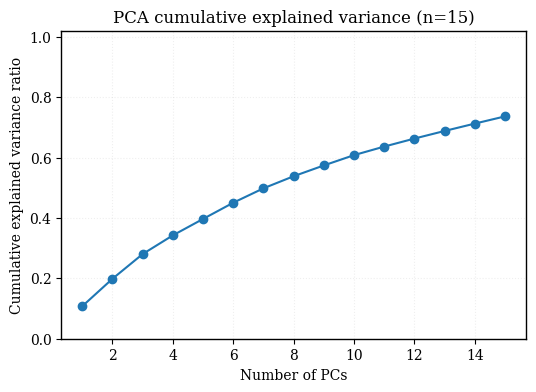

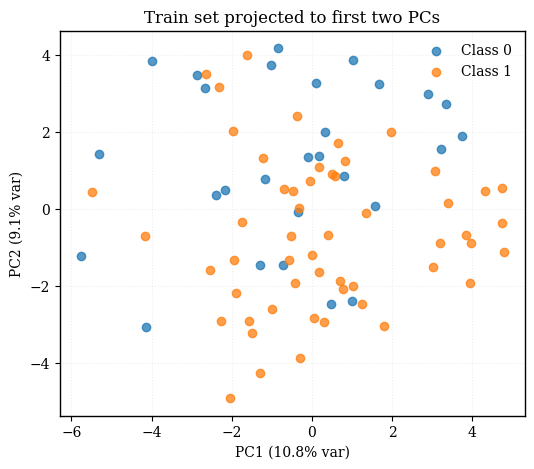

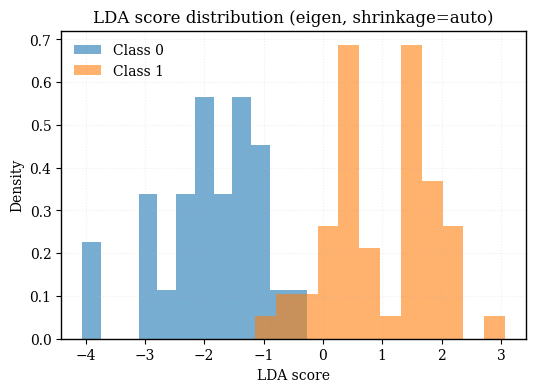

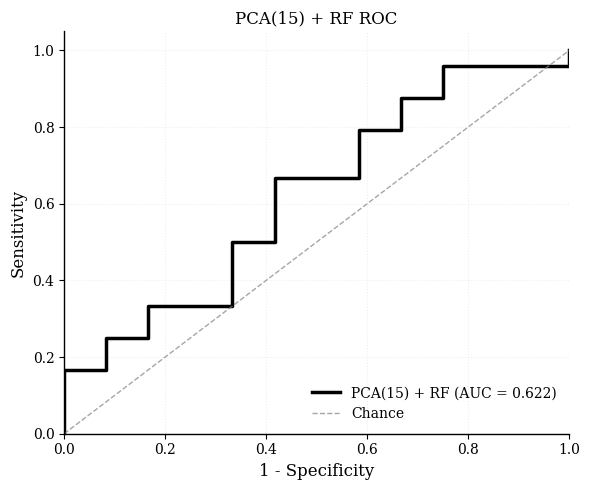

[SAVED] /content/drive/MyDrive/BLiP/out/VAE_ROC_Plots/Figure_ROC_PCA15_RF.png
[INFO] PCA(15) + RF test AUC = 0.622


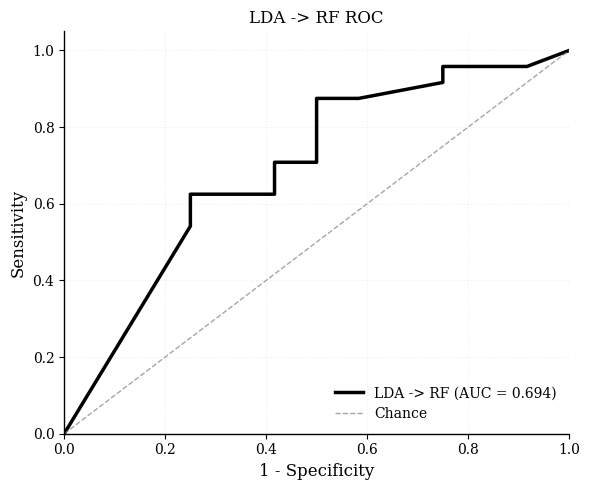

[SAVED] /content/drive/MyDrive/BLiP/out/VAE_ROC_Plots/Figure_ROC_LDA_to_RF.png
[INFO] LDA -> RF test AUC = 0.694


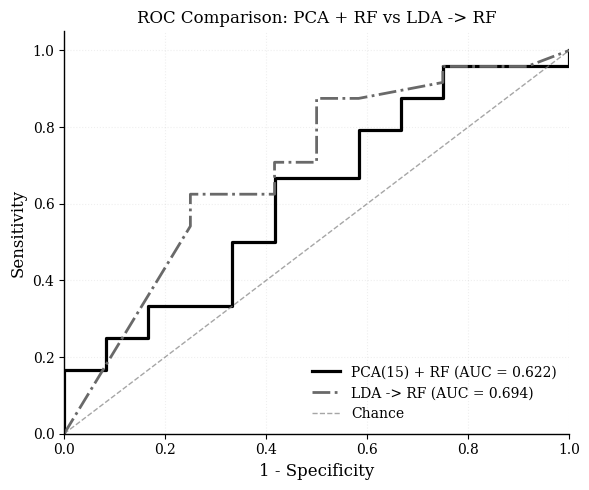

[SAVED] /content/drive/MyDrive/BLiP/out/VAE_ROC_Plots/Figure_ROC_Comparison_PCA_RF_vs_LDA_to_RF.png


In [22]:
# Cell 6C) Tuned PCA/LDA plots + black ROC plots

import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve


plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.linewidth"] = 1.0

# -------------------------------------------------
# 1) PCA cumulative explained variance
# -------------------------------------------------
plt.figure(figsize=(6, 4))
x = np.arange(1, best_pca_n + 1)
plt.plot(x, pca_full.explained_variance_ratio_.cumsum(), marker="o")
plt.xlabel("Number of PCs")
plt.ylabel("Cumulative explained variance ratio")
plt.title(f"PCA cumulative explained variance (n={best_pca_n})")
plt.ylim(0, 1.02)
plt.grid(alpha=0.2, linestyle=":")
plt.show()

# -------------------------------------------------
# 2) PCA 2D scatter
# -------------------------------------------------
plt.figure(figsize=(6, 5))
for cls, label in [(0, "Class 0"), (1, "Class 1")]:
    idx = (ytr == cls)
    plt.scatter(
        Zp_train_2d[idx, 0],
        Zp_train_2d[idx, 1],
        alpha=0.75,
        label=label,
    )

plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("Train set projected to first two PCs")
plt.legend(frameon=False)
plt.grid(alpha=0.2, linestyle=":")
plt.show()

# -------------------------------------------------
# 3) LDA 1D distribution
# -------------------------------------------------
plt.figure(figsize=(6, 4))
plt.hist(Zl_train[ytr == 0, 0], bins=12, alpha=0.6, density=True, label="Class 0")
plt.hist(Zl_train[ytr == 1, 0], bins=12, alpha=0.6, density=True, label="Class 1")
plt.xlabel("LDA score")
plt.ylabel("Density")
plt.title(f"LDA score distribution ({best_lda_proj_solver}, shrinkage={best_lda_proj_shrinkage})")
plt.legend(frameon=False)
plt.grid(alpha=0.2, linestyle=":")
plt.show()

# -------------------------------------------------
# 4) ROC helper
# -------------------------------------------------
def plot_clean_roc(
    y_true,
    proba,
    title,
    curve_label,
    filename,
    save_folder,
    line_color="black",
    line_style="-",
    line_width=2.5,
):
    auc = float(roc_auc_score(y_true, proba))
    fpr, tpr, _ = roc_curve(y_true, proba)

    plt.figure(figsize=(6, 5))

    plt.plot(
        fpr,
        tpr,
        lw=line_width,
        color=line_color,
        ls=line_style,
        label=f"{curve_label} (AUC = {auc:.3f})"
    )

    plt.plot(
        [0, 1], [0, 1],
        color="gray",
        lw=1.0,
        ls="--",
        alpha=0.7,
        label="Chance"
    )

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])

    plt.xlabel("1 - Specificity", fontsize=12)
    plt.ylabel("Sensitivity", fontsize=12)
    plt.title(title, fontsize=12)

    plt.legend(loc="lower right", fontsize=10, frameon=False)
    plt.grid(alpha=0.2, ls=":")

    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    save_path = os.path.join(save_folder, filename)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"[SAVED] {save_path}")
    print(f"[INFO] {curve_label} test AUC = {auc:.3f}")

    return {
        "auc": auc,
        "fpr": fpr,
        "tpr": tpr,
        "save_path": save_path,
    }

# -------------------------------------------------
# 5) Single ROC plots
# -------------------------------------------------
pca_rf_roc = plot_clean_roc(
    y_true=yte,
    proba=np.asarray(pca_test_proba).ravel(),
    title=f"PCA({best_pca_n}) + RF ROC",
    curve_label=f"PCA({best_pca_n}) + RF",
    filename=f"Figure_ROC_PCA{best_pca_n}_RF.png",
    save_folder=save_folder,
)

lda_rf_roc = plot_clean_roc(
    y_true=yte,
    proba=np.asarray(lda_test_proba).ravel(),
    title="LDA -> RF ROC",
    curve_label=f"LDA -> RF",
    filename="Figure_ROC_LDA_to_RF.png",
    save_folder=save_folder,
)

# -------------------------------------------------
# 6) Comparison ROC
# -------------------------------------------------
plt.figure(figsize=(6, 5))

plt.plot(
    pca_rf_roc["fpr"],
    pca_rf_roc["tpr"],
    lw=2.3,
    color="black",
    label=f"PCA({best_pca_n}) + RF (AUC = {pca_rf_roc['auc']:.3f})"
)

plt.plot(
    lda_rf_roc["fpr"],
    lda_rf_roc["tpr"],
    lw=2.0,
    color="dimgray",
    ls="-.",
    label=f"LDA -> RF (AUC = {lda_rf_roc['auc']:.3f})"
)

plt.plot(
    [0, 1], [0, 1],
    color="gray",
    lw=1.0,
    ls="--",
    alpha=0.7,
    label="Chance"
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel("1 - Specificity", fontsize=12)
plt.ylabel("Sensitivity", fontsize=12)
plt.title("ROC Comparison: PCA + RF vs LDA -> RF", fontsize=12)

plt.legend(loc="lower right", fontsize=10, frameon=False)
plt.grid(alpha=0.2, ls=":")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

combined_path = os.path.join(save_folder, "Figure_ROC_Comparison_PCA_RF_vs_LDA_to_RF.png")
plt.savefig(combined_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"[SAVED] {combined_path}")

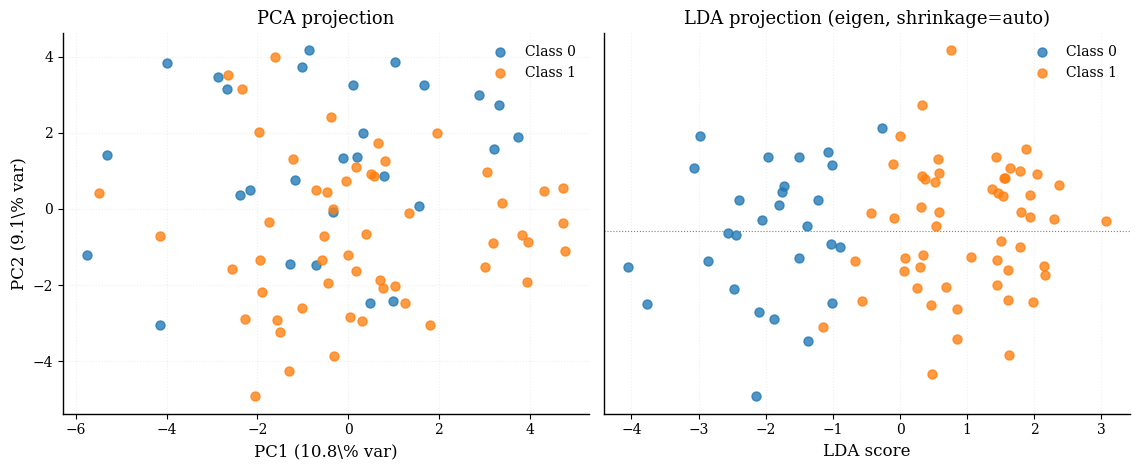

[SAVED] /content/drive/MyDrive/BLiP/out/VAE_ROC_Plots/Figure_PCA_LDA_projection_examples.png


In [23]:
# Paper-style two-panel projection figure
# PCA 2D scatter + LDA 1D jitter scatter
# (No global title)

import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis




plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.linewidth"] = 1.0

# -------------------------------------------------
# base input
# -------------------------------------------------
Xb_train = np.asarray(X_final_train, dtype=np.float32)
ytr = np.asarray(y_train_np).astype(int).ravel()

# -------------------------------------------------
# refit projections for plotting
# -------------------------------------------------
pca_2d = PCA(n_components=2)
Zp_train_2d = pca_2d.fit_transform(Xb_train)

lda_proj = LinearDiscriminantAnalysis(
    n_components=1,
    solver=best_lda_proj_solver,
    shrinkage=best_lda_proj_shrinkage,
)
Zl_train = lda_proj.fit_transform(Xb_train, ytr).ravel()

# reproducible jitter
rng = np.random.default_rng(42)
jitter0 = rng.normal(loc=0.0, scale=0.045, size=(ytr == 0).sum())
jitter1 = rng.normal(loc=0.0, scale=0.045, size=(ytr == 1).sum())

# -------------------------------------------------
# figure
# -------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))

# -------------------------
# (A) PCA 2D scatter
# -------------------------
for cls, label in [(0, "Class 0"), (1, "Class 1")]:
    idx = (ytr == cls)
    axes[0].scatter(
        Zp_train_2d[idx, 0],
        Zp_train_2d[idx, 1],
        alpha=0.78,
        s=42,
        label=label,
    )

axes[0].set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}\\% var)", fontsize=12)
axes[0].set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}\\% var)", fontsize=12)
axes[0].set_title("PCA projection", fontsize=13)
axes[0].legend(frameon=False, fontsize=10, loc="upper right")
axes[0].grid(alpha=0.2, linestyle=":")

# -------------------------
# (B) LDA 1D jitter scatter
# -------------------------
idx0 = (ytr == 0)
idx1 = (ytr == 1)

axes[1].scatter(
    Zl_train[idx0],
    jitter0,
    alpha=0.78,
    s=42,
    label="Class 0",
)

axes[1].scatter(
    Zl_train[idx1],
    jitter1,
    alpha=0.78,
    s=42,
    label="Class 1",
)

axes[1].axhline(0, color="gray", lw=0.8, ls=":")
axes[1].set_xlabel("LDA score", fontsize=12)
axes[1].set_ylabel("")
axes[1].set_yticks([])
axes[1].set_title(
    f"LDA projection ({best_lda_proj_solver}, shrinkage={best_lda_proj_shrinkage})",
    fontsize=13,
)
axes[1].legend(frameon=False, fontsize=10, loc="upper right")
axes[1].grid(alpha=0.2, linestyle=":")

# paper-style spines
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.tight_layout()

out_path = os.path.join(save_folder, "Figure_PCA_LDA_projection_examples.png")
fig.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"[SAVED] {out_path}")